In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords  #stopwords
import nltk

In [2]:
df = pd.read_csv('netflix_dataset.csv')

In [3]:
df.sample(50)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7081,s7082,TV Show,Inside the Mind of a Serial Killer,NaN,NaN,United States,"July 1, 2019",2015,TV-14,1 Season,"Crime TV Shows, Docuseries",Mixing dramatic re-enactments with real-life f...
4551,s4552,TV Show,Monty Python's Flying Circus,NaN,"John Cleese, Graham Chapman, Terry Jones, Eric...",United Kingdom,"October 2, 2018",1974,TV-14,4 Seasons,"British TV Shows, Classic & Cult TV, Internati...",The Monty Python players make their mark with ...
6340,s6341,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,"March 1, 2016",2016,R,90 min,Comedies,New NFL star Thad buys his old teammates' belo...
663,s664,TV Show,Charité at War,NaN,"Mala Emde, Ulrich Noethen, Jannik Schümann, Ar...",NaN,"June 19, 2021",2019,TV-MA,1 Season,"International TV Shows, TV Dramas","In 1943, the staff at Berlin's Charité hospita..."
6712,s6713,Movie,Every Time I Die,Robi Michael,"Drew Fonteiro, Marc Menchaca, Michelle Macedo,...",United States,"February 25, 2020",2019,TV-MA,98 min,"Dramas, Independent Movies, Thrillers",After a paramedic’s violent death during a wee...
6019,s6020,Movie,50/50,Jonathan Levine,"Joseph Gordon-Levitt, Seth Rogen, Anna Kendric...",United States,"June 1, 2019",2011,R,100 min,"Comedies, Dramas, Independent Movies",An otherwise healthy twentysomething has a com...
3211,s3212,Movie,Kalushi: The Story of Solomon Mahlangu,Mandla Dube,"Thabo Rametsi, Thabo Malema, Welile Nzuza, Jaf...",South Africa,"November 29, 2019",2016,TV-MA,107 min,"Dramas, International Movies",The life and times of iconic South African lib...
7541,s7542,Movie,My Little Pony Equestria Girls: Friendship Games,"Ishi Rudell, Jayson Thiessen","Tara Strong, Rebecca Shoichet, Ashleigh Ball, ...","United States, Canada","December 1, 2015",2015,TV-Y,72 min,"Children & Family Movies, Comedies","Rainbow Dash, Applejack and friends compete ag..."
7370,s7371,Movie,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,"November 1, 2010",1987,NR,84 min,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott..."
5539,s5540,Movie,The Lighthouse of the Orcas,Gerardo Olivares,"Maribel Verdú, Joaquín Furriel, Joaquín Rapalini","Spain, Argentina","April 7, 2017",2016,TV-MA,110 min,"Dramas, International Movies, Romantic Movies",A mother travels to Patagonia with her autisti...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.shape

(8807, 12)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

Duplicate values has been removed.

In [9]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


<Axes: >

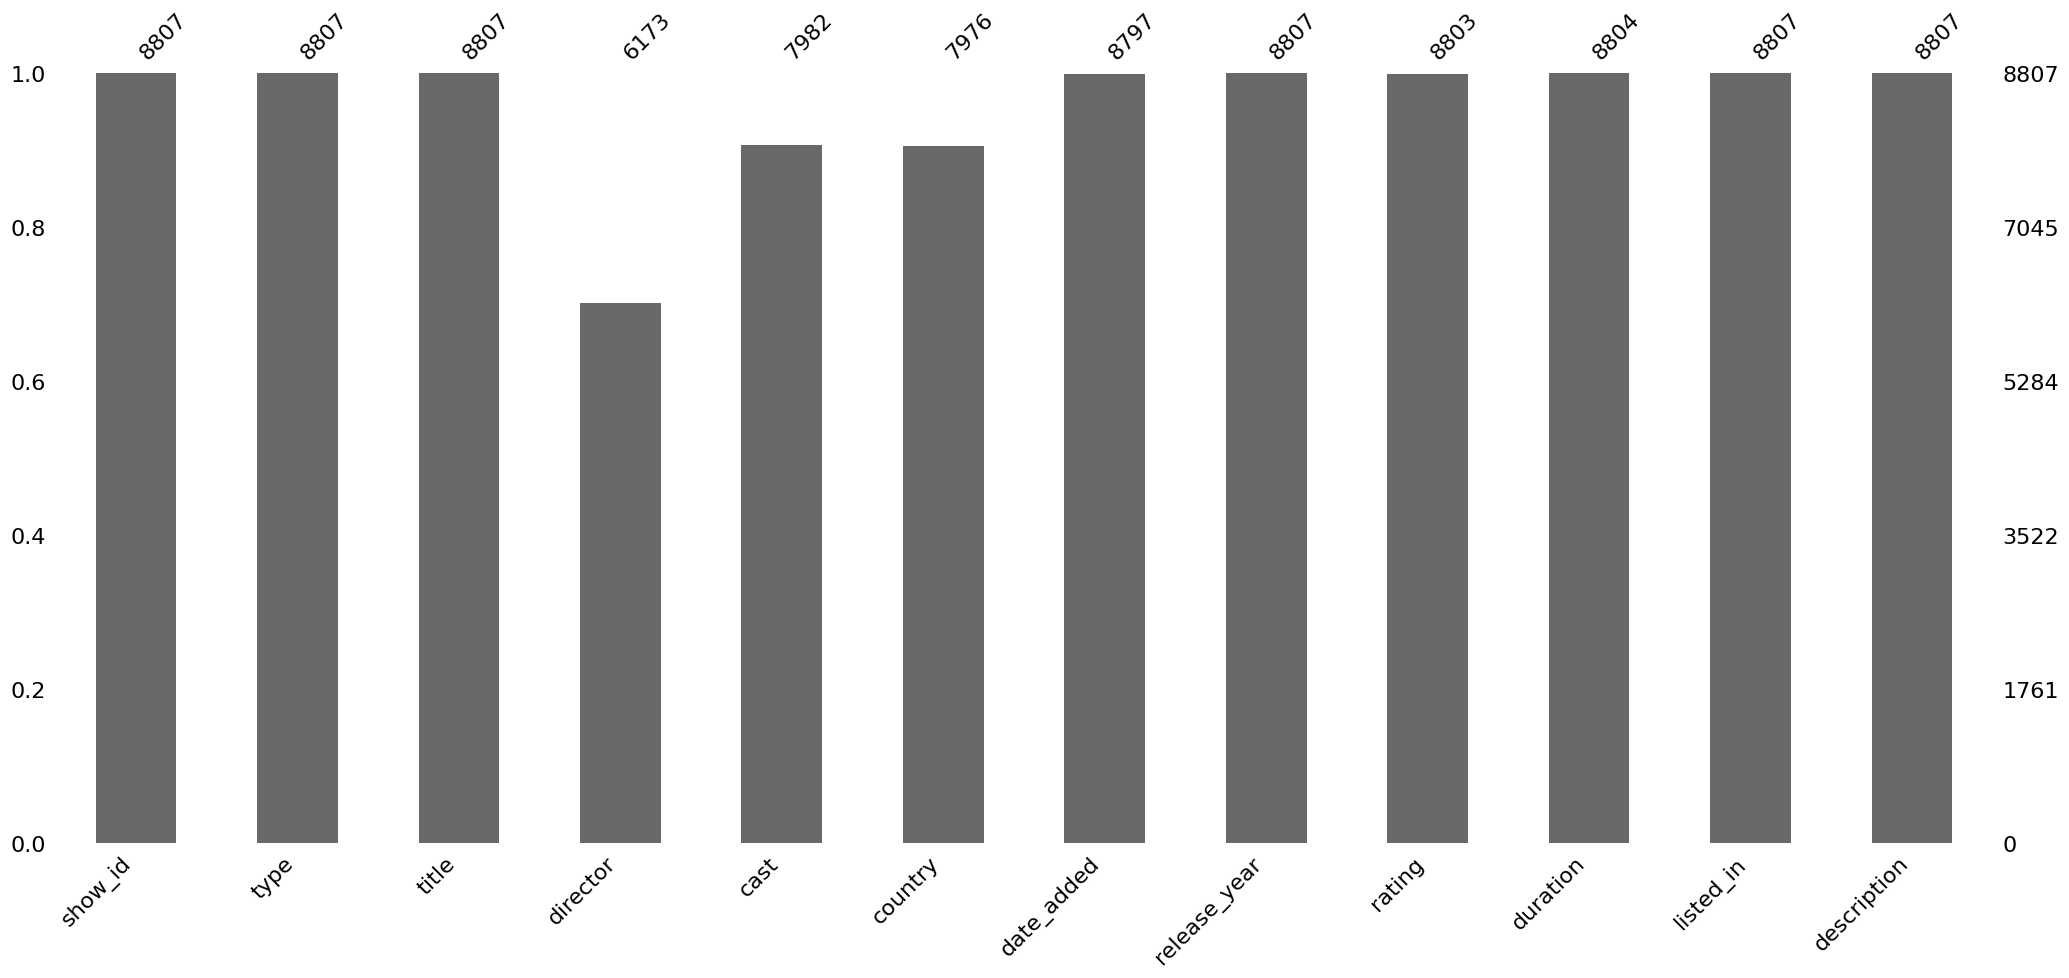

In [10]:
import missingno as msno
msno.bar(df)

/tmp/ipykernel_25599/4069455268.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")
/tmp/ipykernel_25599/4069455268.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, missing_values[i] + 0.5, f'{missing_values[i]}', ha='center', va='bottom', fontsize=12)


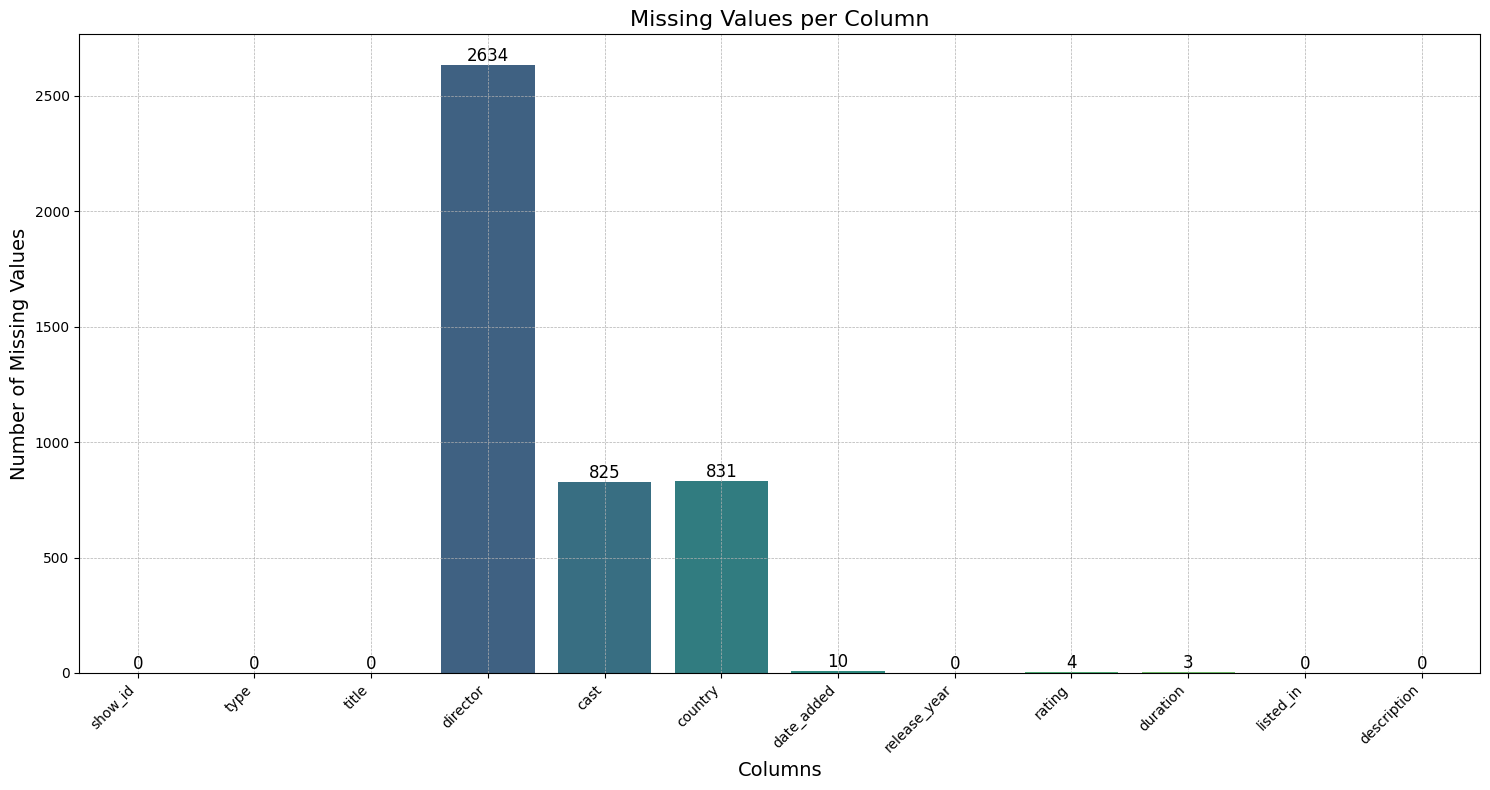

In [11]:
# Create the figure and axis
plt.figure(figsize=(15, 8))

# Calculate the number of missing values in each column
missing_values = df.isna().sum()

# Plot the missing values as a barplot
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")

# Customize the plot
plt.title('Missing Values per Column', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Number of Missing Values', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', linewidth=0.5)

# Annotate each bar with the number of missing values
for i in range(missing_values.shape[0]):
    plt.text(i, missing_values[i] + 0.5, f'{missing_values[i]}', ha='center', va='bottom', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

**Missing value columns**
1. release_date (10) and rating (7) are nearly complete — negligible gaps, easy to handle by dropping those rows.

2. Dealing with High Null Percentages in director and cast: For columns like director and cast, where the null percentage is significantly higher, removing or imputing values could result in substantial data loss or misrepresentation. Instead, we will replace these missing entries with 'unknown', preserving the integrity of the dataset while acknowledging the absence of specific details.

3.Imputing Missing Values in country with Mode: The country column has about 9.4% missing values, which is relatively low.Here we will impute the missing values with the mode. This choice maintains the dataset's consistency while leveraging the dominant data trend.

<Axes: >

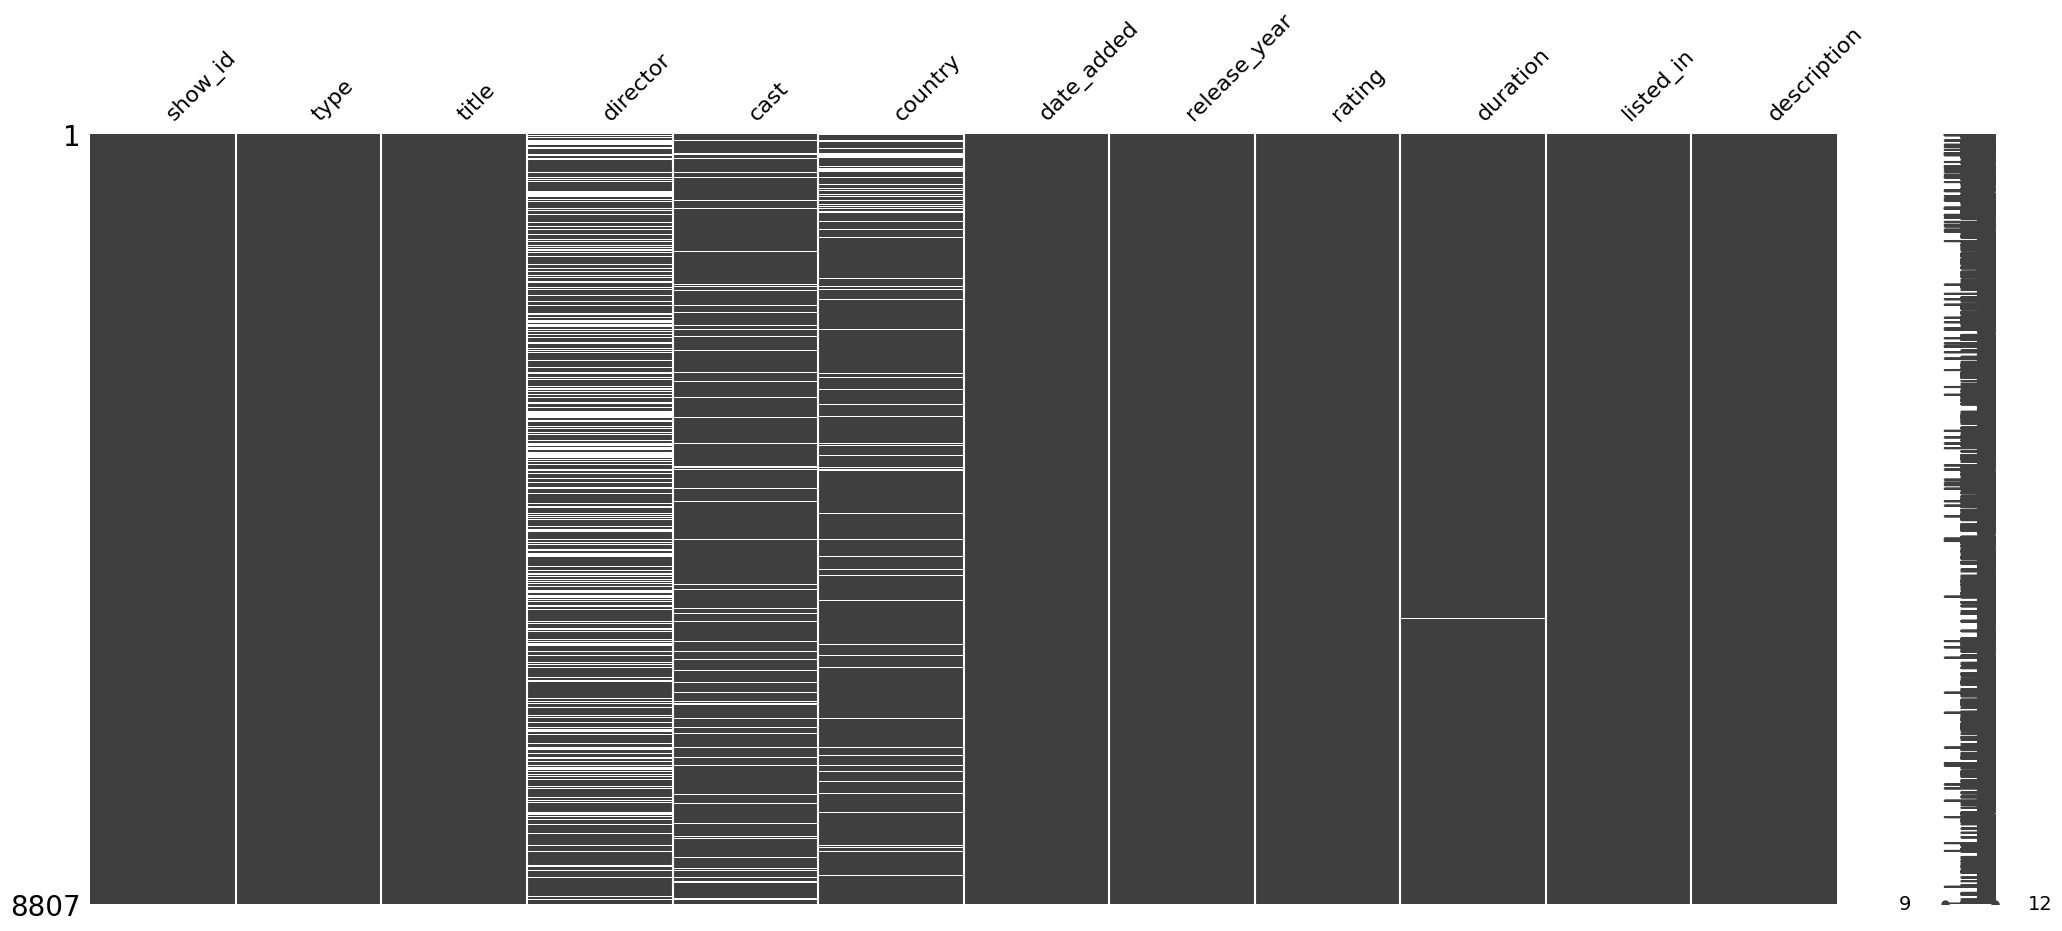

In [12]:
msno.matrix(df)

<Axes: >

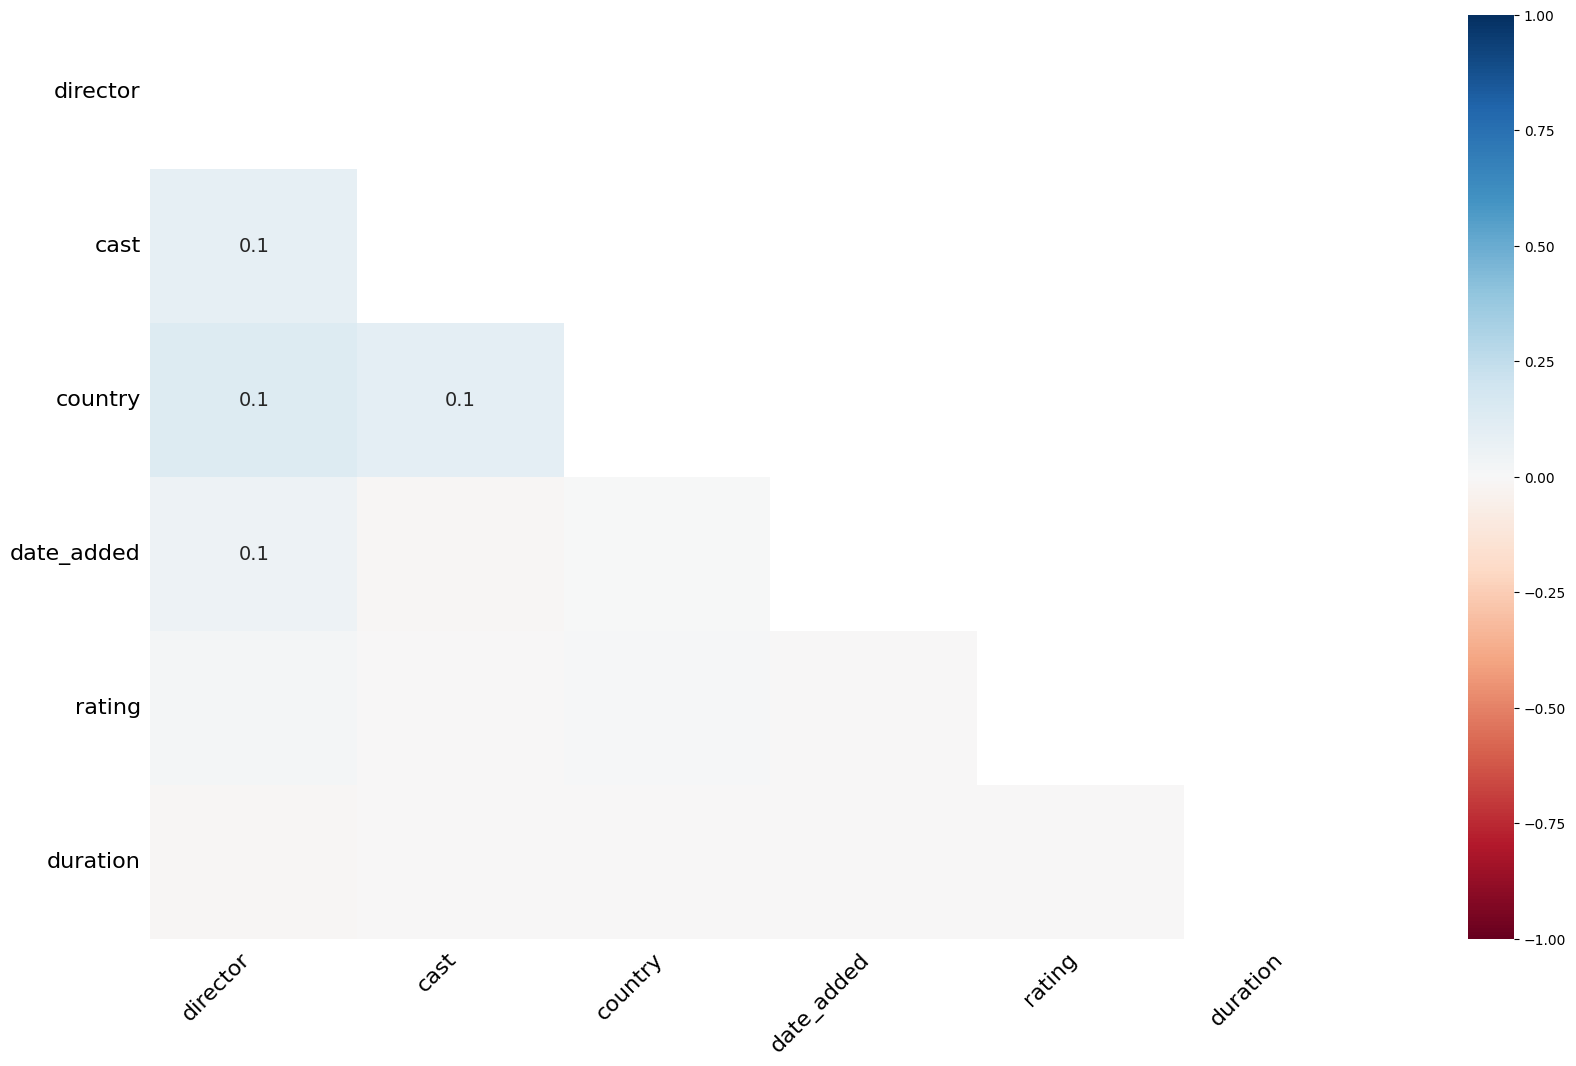

In [13]:
msno.heatmap(df)

In [14]:
df[['director','cast']]=df[['director','cast']].fillna("Unknown")

# Imputing null values of country with Mode
df['country']=df['country'].fillna(df['country'].mode()[0])

# Dropping remaining null values of date_added and rating
df.dropna(axis=0, inplace=True)

In [15]:
df['country'].mode()[0]

'United States'

In [16]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [17]:
df_copy=df.copy()
df_copy.head() # maintain a copy of dataset

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### **Director, Cast, Country, Type columns are nested.**

In [18]:
# Let's create a copy of dataframe and unnest the original one
df_new=df.copy()
df_new.shape

(8790, 12)

In [19]:
df_new.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [20]:
# Unnesting 'Directors' column
dir_constraint=df['director'].apply(lambda x: str(x).split(', ')).tolist()
df1 = pd.DataFrame(dir_constraint, index = df['title'])
df1 = df1.stack()
df1 = pd.DataFrame(df1.reset_index())
df1.rename(columns={0:'Directors'},inplace=True)
df1 = df1.drop(['level_1'],axis=1)
df1.sample(10)

,title,Directors
7332,For Grace,Kevin Pang
3003,The Occupant,Àlex Pastor
8456,Power Rangers Zeo,Unknown
6869,Bolt,Byron Howard
7973,Lucky: No Time for Love,Vinay Sapru
4744,"All's Well, End's Well (2009)",Vincent Kok
5339,Revolt,Joe Miale
5738,Undefeated,Daniel Lindsay
7115,Dear Dracula,Chad Van De Keere
4298,Charlie's Colorforms City,Unknown


In [21]:
df1.shape

(9595, 2)

In [22]:
df1[df1['title']=='21 & Over']

,title,Directors
6484,21 & Over,Jon Lucas
6485,21 & Over,Scott Moore


In [23]:
# Unnesting 'cast' column
cast_constraint=df['cast'].apply(lambda x: str(x).split(', ')).tolist()
df2 = pd.DataFrame(cast_constraint, index = df['title'])
df2 = df2.stack()
df2 = pd.DataFrame(df2.reset_index())
df2.rename(columns={0:'Actors'},inplace=True)
df2 = df2.drop(['level_1'],axis=1)
df2.sample(10)

,title,Actors
43344,Jeff Foxworthy and Larry the Cable Guy: We’ve ...,Larry the Cable Guy
2353,SHAMAN KING,Nana Mizuki
49519,Encounter: The Killing,Dilip Prabhavalkar
56806,Pitaah,Anjan Srivastav
10937,Invisible City,Fábio Lago
6369,Sweet Tooth,Dania Ramirez
17225,The Legend of Korra,P.J. Byrne
44852,A Patch of Fog,Stuart Graham
44096,Victim of Beauty,Nick Searcy
9207,Woody Woodpecker,Chelsea Miller


In [24]:
df2[df2['title']=='Doctor Foster']

,title,Actors
37607,Doctor Foster,Suranne Jones
37608,Doctor Foster,Bertie Carvel
37609,Doctor Foster,Clare-Hope Ashitey
37610,Doctor Foster,Cheryl Campbell
37611,Doctor Foster,Jodie Comer
37612,Doctor Foster,Victoria Hamilton
37613,Doctor Foster,Martha Howe-Douglas
37614,Doctor Foster,Adam James
37615,Doctor Foster,Thusitha Jayasundera
37616,Doctor Foster,Sara Stewart


In [25]:
type_constraint=df['type'].apply(lambda x: str(x).split(',')).tolist()
df3 = pd.DataFrame(type_constraint,index=df['title'])
df3 =df3.stack()
df3 = pd.DataFrame(df3.reset_index())
df3.rename(columns={0:'type'},inplace=True)
df3 = df3.drop(['level_1'],axis=1)
df3.sample(10)

,title,type
5961,Feb-09,TV Show
2419,Big Stone Gap,Movie
7614,Nurses Who Kill,TV Show
6580,Deep Undercover Collection,TV Show
5639,We're Lalaloopsy,TV Show
6078,Acapulco La vida va,Movie
4822,Us and Them,Movie
4234,Gina Yashere: Laughing to America,Movie
5678,Asperger's Are Us,Movie
7573,Ninja Hattori,TV Show


In [26]:
print("shape of df1 ",df1.shape)
print("shape of df2 ",df2.shape)
print("shape of df3 ",df3.shape)

shape of df1  (9595, 2)
shape of df2  (64841, 2)
shape of df3  (8790, 2)


In [27]:
# Unnesting 'country' column
country_constraint=df['country'].apply(lambda x: str(x).split(', ')).tolist()
df4 = pd.DataFrame(country_constraint, index = df['title'])
df4 = df4.stack()
df4 = pd.DataFrame(df4.reset_index())
df4.rename(columns={0:'Country'},inplace=True)
df4 = df4.drop(['level_1'],axis=1)
df4.sample(10)

,title,Country
2465,Aapla Manus,India
8852,Little Singham in London,United States
4390,Whitney Cummings: Can I Touch It?,United States
4119,10 Days in Sun City,South Africa
9059,"Monster High: Boo York, Boo York",United States
8011,East Side Sushi,United States
1223,Miss Sloane,Canada
7804,Coach Carter,United States
3841,Nothing to Lose 2,Brazil
9799,Soul Surfer,United States


In [28]:
# Unnesting 'listed_in' column
listed_constraint=df['listed_in'].apply(lambda x: str(x).split(', ')).tolist()
df3 = pd.DataFrame(listed_constraint, index = df['title'])
df3 = df3.stack()
df3 = pd.DataFrame(df3.reset_index())
df3.rename(columns={0:'Genre'},inplace=True)
df3 = df3.drop(['level_1'],axis=1)
df3.sample(10)

,title,Genre
199,Titipo Titipo,Kids' TV
16993,Person of Interest,TV Action & Adventure
12371,Our Lovers,International Movies
8838,Pinky Memsaab,Independent Movies
18089,The Chefs' Line,International TV Shows
6845,How High 2,Comedies
4515,"Take the Ball, Pass the Ball",International Movies
14122,Caida del Cielo,Comedies
10014,The Great British Baking Show: The Beginnings,Reality TV
11073,Pickpockets,International Movies


**Nested columns are handled**

In [29]:
## Merging all the unnested dataframes
# Merging director and cast
df5 = df2.merge(df1,on=['title'],how='inner')

# Merging listed_in with merged of (director and cast)
df6 = df5.merge(df3,on=['title'],how='inner')

# Merging country with merged of [listed_in with merged of (director and cast)]
df7 = df6.merge(df4,on=['title'],how='inner')

# Head of final merged dataframe
df7.head(5)

,title,Actors,Directors,Genre,Country
0,Dick Johnson Is Dead,Unknown,Kirsten Johnson,Documentaries,United States
1,Blood & Water,Ama Qamata,Unknown,International TV Shows,South Africa
2,Blood & Water,Ama Qamata,Unknown,TV Dramas,South Africa
3,Blood & Water,Ama Qamata,Unknown,TV Mysteries,South Africa
4,Blood & Water,Khosi Ngema,Unknown,International TV Shows,South Africa


In [30]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [31]:
# Merging unnested data with the created dataframe in order to make the final dataframe
df = df7.merge(df[['type', 'title', 'date_added', 'release_year', 'rating', 'duration','description']],on=['title'],how='left')
df.head()

,title,Actors,Directors,Genre,Country,type,date_added,release_year,rating,duration,description
0,Dick Johnson Is Dead,Unknown,Kirsten Johnson,Documentaries,United States,Movie,"September 25, 2021",2020,PG-13,90 min,"As her father nears the end of his life, filmm..."
1,Blood & Water,Ama Qamata,Unknown,International TV Shows,South Africa,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t..."
2,Blood & Water,Ama Qamata,Unknown,TV Dramas,South Africa,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t..."
3,Blood & Water,Ama Qamata,Unknown,TV Mysteries,South Africa,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t..."
4,Blood & Water,Khosi Ngema,Unknown,International TV Shows,South Africa,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"After crossing paths at a party, a Cape Town t..."


In [32]:
df.shape

(201763, 11)

In [33]:
df.duplicated().sum()

np.int64(55)

In [34]:
df.drop_duplicates(inplace=True)

In [35]:
df.duplicated().sum()

np.int64(0)

**Type casting of attributes**

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201708 entries, 0 to 201762
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   title         201708 non-null  object
 1   Actors        201708 non-null  object
 2   Directors     201708 non-null  object
 3   Genre         201708 non-null  object
 4   Country       201708 non-null  object
 5   type          201708 non-null  object
 6   date_added    201708 non-null  object
 7   release_year  201708 non-null  int64 
 8   rating        201708 non-null  object
 9   duration      201708 non-null  object
 10  description   201708 non-null  object
dtypes: int64(1), object(10)
memory usage: 18.5+ MB


In [37]:
#Typecasting duration into integer by removing 'min' and 'season' from the end
df['duration'] = df['duration'].apply(lambda x: int(x.split()[0]) if isinstance(x, str) else x)
df['duration'].sample(5)

,duration
146098,96
80262,1
77255,106
149321,108
56195,130


In [38]:
# Typecasting string object to datetime object of date_added column
# Strip extra spaces before converting to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')
# Extracting date, day, month and year from date_added column
df["day_added"] = df["date_added"].dt.day
df["month_added"] = df["date_added"].dt.month
df["year_added"] =df["date_added"].dt.year

# Dropping date_added
df.drop('date_added', axis=1, inplace=True)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201708 entries, 0 to 201762
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   title         201708 non-null  object
 1   Actors        201708 non-null  object
 2   Directors     201708 non-null  object
 3   Genre         201708 non-null  object
 4   Country       201708 non-null  object
 5   type          201708 non-null  object
 6   release_year  201708 non-null  int64 
 7   rating        201708 non-null  object
 8   duration      201708 non-null  int64 
 9   description   201708 non-null  object
 10  day_added     201708 non-null  int32 
 11  month_added   201708 non-null  int32 
 12  year_added    201708 non-null  int32 
dtypes: int32(3), int64(2), object(8)
memory usage: 19.2+ MB


In [40]:
df.head()

,title,Actors,Directors,Genre,Country,type,release_year,rating,duration,description,day_added,month_added,year_added
0,Dick Johnson Is Dead,Unknown,Kirsten Johnson,Documentaries,United States,Movie,2020,PG-13,90,"As her father nears the end of his life, filmm...",25,9,2021
1,Blood & Water,Ama Qamata,Unknown,International TV Shows,South Africa,TV Show,2021,TV-MA,2,"After crossing paths at a party, a Cape Town t...",24,9,2021
2,Blood & Water,Ama Qamata,Unknown,TV Dramas,South Africa,TV Show,2021,TV-MA,2,"After crossing paths at a party, a Cape Town t...",24,9,2021
3,Blood & Water,Ama Qamata,Unknown,TV Mysteries,South Africa,TV Show,2021,TV-MA,2,"After crossing paths at a party, a Cape Town t...",24,9,2021
4,Blood & Water,Khosi Ngema,Unknown,International TV Shows,South Africa,TV Show,2021,TV-MA,2,"After crossing paths at a party, a Cape Town t...",24,9,2021


**<h2>3.4 Binning of Rating attribute</h2>**

In rating columns we have different categories these are content rating classifications that are commonly used in the United States and other countries to indicate the appropriateness of media content for different age groups. Let's understand each of them and binnig them accordingly:

TV-MA: This rating is used for mature audiences only, and it may contain strong language, violence, nudity, and sexual content.

R: This rating is used for movies that are intended for audiences 17 and older. It may contain graphic violence, strong language, drug use, and sexual content.

PG-13: This rating is used for movies that may not be suitable for children under 13. It may contain violence, mild to moderate language, and suggestive content.

TV-14: This rating is used for TV shows that may not be suitable for children under 14. It may contain violence, strong language, sexual situations, and suggestive dialogue.

TV-PG: This rating is used for TV shows that may not be suitable for children under 8. It may contain mild violence, language, and suggestive content.

NR: This stands for "Not Rated." It means that the content has not been rated by a rating board, and it may contain material that is not suitable for all audiences.

TV-G: This rating is used for TV shows that are suitable for all ages. It may contain some mild violence, language, and suggestive content.

TV-Y: This rating is used for children's TV shows that are suitable for all ages. It is intended to be appropriate for preschool children.

TV-Y7: This rating is used for children's TV shows that may not be suitable for children under 7. It may contain mild violence and scary content.

PG: This rating is used for movies that may not be suitable for children under 10. It may contain mild language, some violence, and some suggestive content.

G: This rating is used for movies that are suitable for general audiences. It may contain some mild language and some violence.

NC-17: This rating is used for movies that are intended for adults only. It may contain explicit sexual content, violence, and language.

TV-Y7-FV: This rating is used for children's TV shows that may not be suitable for children under 7. It may contain fantasy violence.

UR: This stands for "Unrated." It means that the content has not been rated by a rating board, and it may contain material that is not suitable for all audiences.


**<he>Convert to following :</h2>**

**Adult Content:** TV-MA, NC-17, R

**Children Content:** TV-PG, PG, TV-G, G

**Teen Content:** PG-13, TV-14

**Family-friendly Content:** TV-Y, TV-Y7, TV-Y7-FV

In [41]:
# Binning the values in the rating column
rating_map = {'TV-MA':'Adult Content',
              'R':'Adult Content',
              'PG-13':'Teen Content',
              'TV-14':'Teen Content',
              'TV-PG':'Children Content',
              'NR':'Not Rated',
              'TV-G':'Children Content',
              'TV-Y':'Family-friendly Content',
              'TV-Y7':'Family-friendly Content',
              'PG':'Children Content',
              'G':'Children Content',
              'NC-17':'Adult Content',
              'TV-Y7-FV':'Family-friendly Content',
              'UR':'Not Rated'}

df['rating'].replace(rating_map, inplace = True)
df['rating'].unique()

/tmp/ipykernel_25599/1663535565.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].replace(rating_map, inplace = True)


array(['Teen Content', 'Adult Content', 'Children Content',
       'Family-friendly Content', 'Not Rated'], dtype=object)

In [42]:
df.shape

(201708, 13)

**<h1>Data Visualisation:Understand the relationship between the features.</h1>**

In [43]:
# Spearating the dataframes for further analysis
df_movies= df[df['type']== 'Movie']
df_tvshows= df[df['type']== 'TV Show']

# Printing the shape
print(df_movies.shape, df_tvshows.shape)
df_movies

(145776, 13) (55932, 13)


,title,Actors,Directors,Genre,Country,type,release_year,rating,duration,description,day_added,month_added,year_added
0,Dick Johnson Is Dead,Unknown,Kirsten Johnson,Documentaries,United States,Movie,2020,Teen Content,90,"As her father nears the end of his life, filmm...",25,9,2021
159,My Little Pony: A New Generation,Vanessa Hudgens,Robert Cullen,Children & Family Movies,United States,Movie,2021,Children Content,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021
160,My Little Pony: A New Generation,Vanessa Hudgens,José Luis Ucha,Children & Family Movies,United States,Movie,2021,Children Content,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021
161,My Little Pony: A New Generation,Kimiko Glenn,Robert Cullen,Children & Family Movies,United States,Movie,2021,Children Content,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021
162,My Little Pony: A New Generation,Kimiko Glenn,José Luis Ucha,Children & Family Movies,United States,Movie,2021,Children Content,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201758,Zubaan,Anita Shabdish,Mozez Singh,International Movies,India,Movie,2015,Teen Content,111,A scrappy but poor boy worms his way into a ty...,2,3,2019
201759,Zubaan,Anita Shabdish,Mozez Singh,Music & Musicals,India,Movie,2015,Teen Content,111,A scrappy but poor boy worms his way into a ty...,2,3,2019
201760,Zubaan,Chittaranjan Tripathy,Mozez Singh,Dramas,India,Movie,2015,Teen Content,111,A scrappy but poor boy worms his way into a ty...,2,3,2019
201761,Zubaan,Chittaranjan Tripathy,Mozez Singh,International Movies,India,Movie,2015,Teen Content,111,A scrappy but poor boy worms his way into a ty...,2,3,2019


1. What is the relative percentage of the total number of movies and TV shows on Netflix?

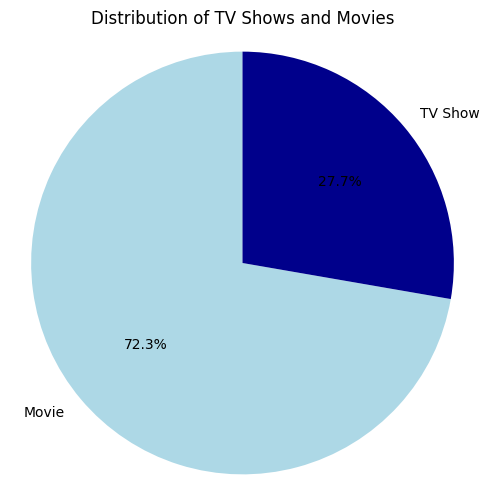

In [44]:
# Calculate the distribution of 'type' (TV Shows and Movies)
type_counts = df['type'].value_counts()

# Assign labels and values for the pie chart
labels = type_counts.index
values = type_counts.values

# Sample data
data = {
    'labels': labels,
    'values': values
}

df_plot = pd.DataFrame(data) # Renamed to df_plot to avoid overwriting the main df

# Colors
colors = ['#ADD8E6', '#00008B']  # Light blue and dark blue

plt.figure(figsize=(6, 6))

plt.pie(
    df_plot['values'], # Use df_plot here
    labels=df_plot['labels'], # Use df_plot here
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of TV Shows and Movies")
plt.axis('equal')  # Makes the pie circular

plt.show()

2. What is the distribution of content on Netflix across different categories?

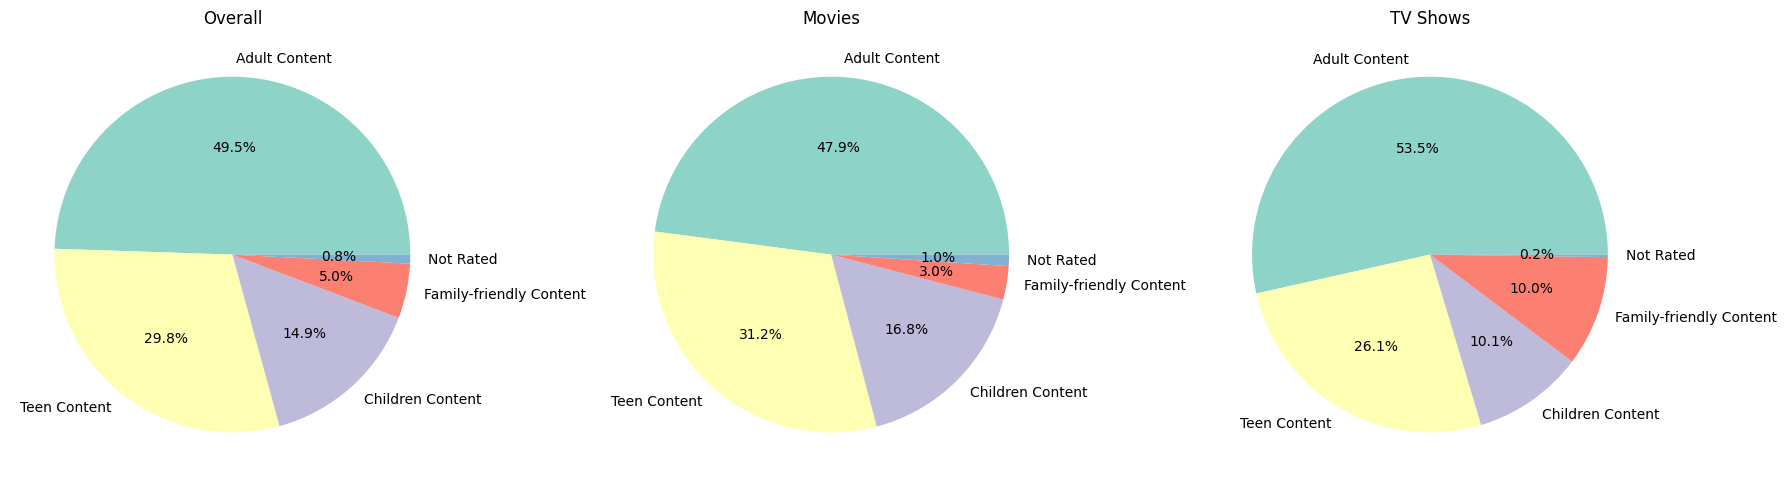

In [45]:
plt.figure(figsize=(18, 6))

# Overall
plt.subplot(1, 3, 1)
df['rating'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors
)
plt.title("Overall")
plt.ylabel("")

# Movies
plt.subplot(1, 3, 2)
df_movies['rating'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors
)
plt.title("Movies")
plt.ylabel("")

# TV Shows
plt.subplot(1, 3, 3)
df_tvshows['rating'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors
)
plt.title("TV Shows")
plt.ylabel("")

plt.tight_layout()
plt.show()


3. Who are the top actors performing in Movies and TV Show?

/tmp/ipykernel_25599/3658528474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Actors",x = 'title', data = df_actor, palette='Set1')
/tmp/ipykernel_25599/3658528474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Actors",x = 'title', data = df_actor, palette='Set1')


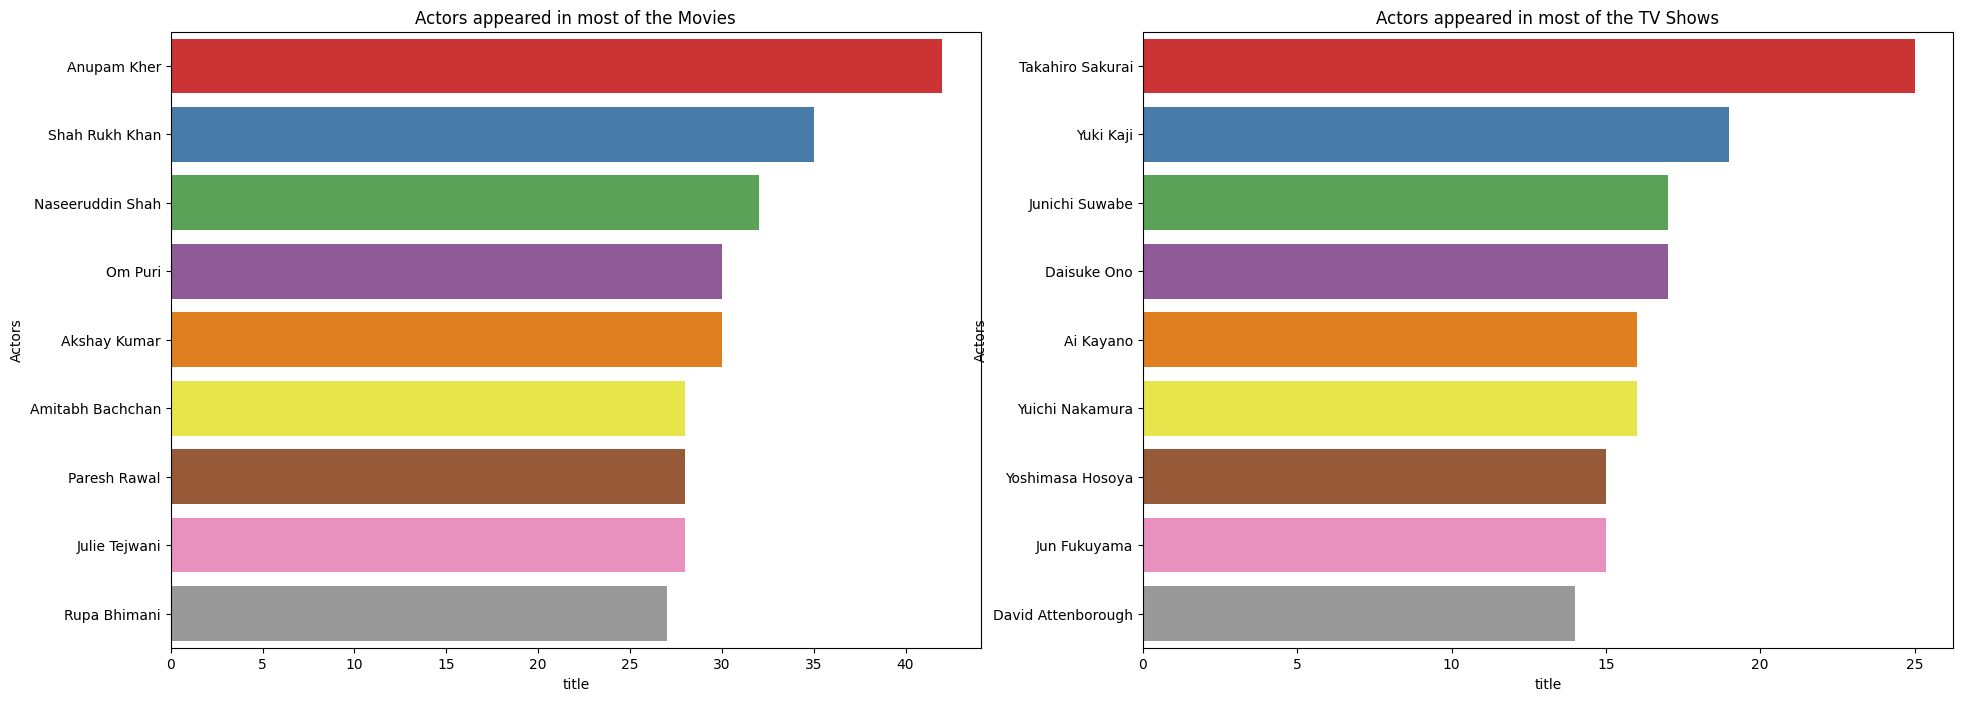

In [46]:
# Top 10 casts in Movies and TV Shows
plt.figure(figsize=(23,8))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_actor = (i.groupby(['Actors'])
              .agg({'title':'nunique'})#On the title column ,Apply the nunique operation.
              .reset_index()#fter groupby, the group key (Actors) becomes the index.
              .sort_values(by=['title'],ascending=False)[1:10]
              )
  plots= sns.barplot(y = "Actors",x = 'title', data = df_actor, palette='Set1')
  plt.title(f'Actors appeared in most of the {j}')
plt.show()

4. Who are the top Directors directing Movies and TV Shows?

/tmp/ipykernel_25599/1511226412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Directors",x = 'title', data = df_director, palette='Paired')
/tmp/ipykernel_25599/1511226412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Directors",x = 'title', data = df_director, palette='Paired')


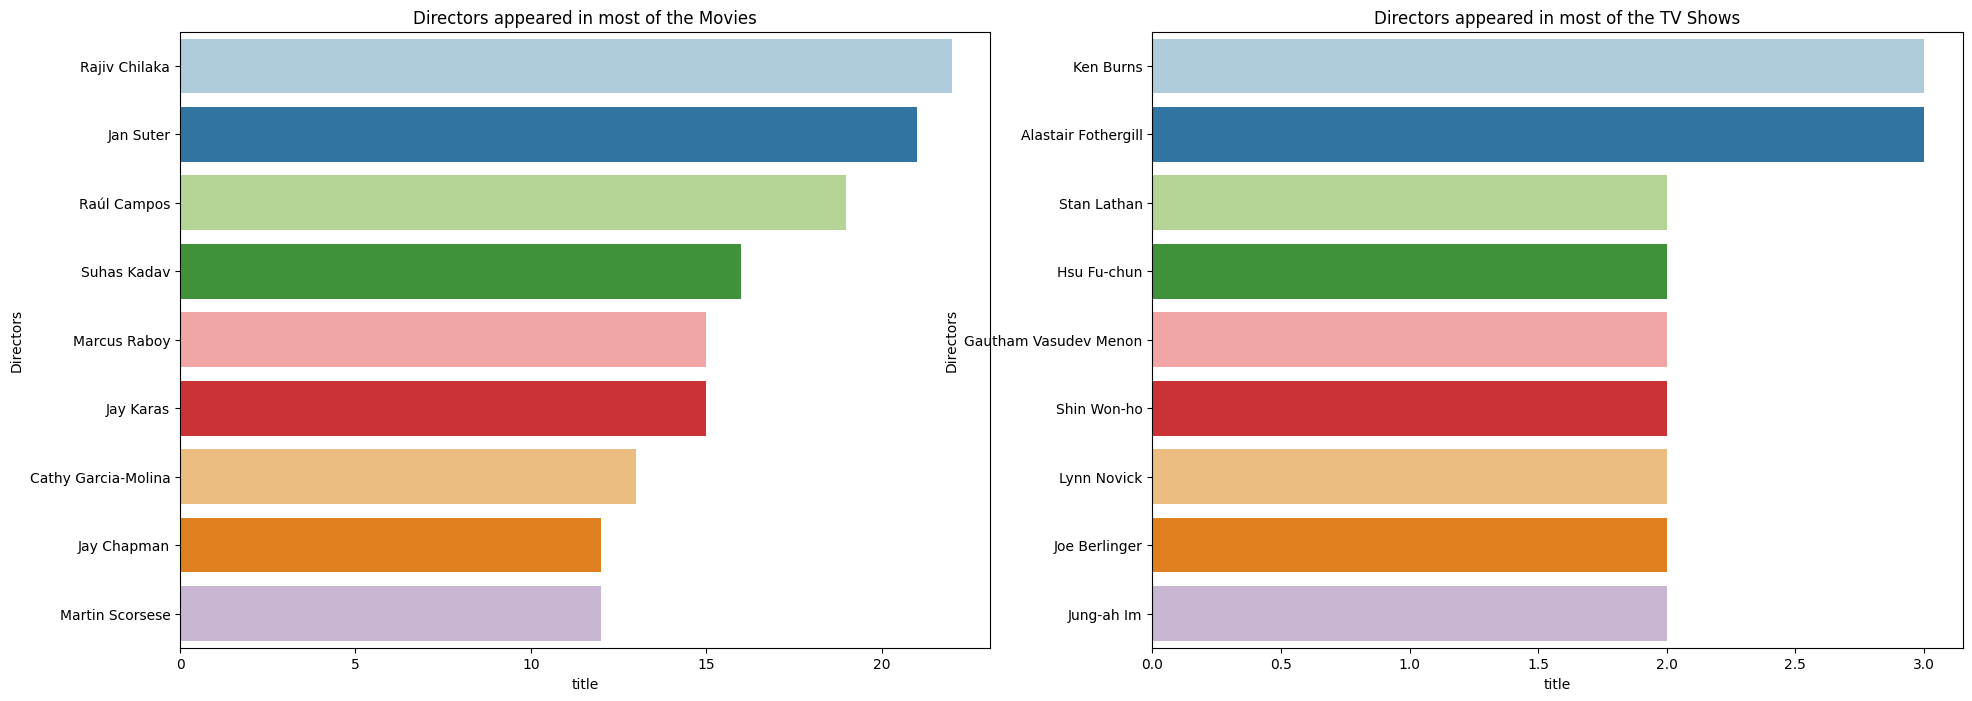

In [47]:
plt.figure(figsize=(23,8))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_director = i.groupby(['Directors']).agg({'title':'nunique'}).reset_index().sort_values(by=['title'],ascending=False)[1:10]
  plots= sns.barplot(y = "Directors",x = 'title', data = df_director, palette='Paired')
  plt.title(f'Directors appeared in most of the {j}')
plt.show()


5. Total Number of Movies/TV Shows added per day on Netflix.

/tmp/ipykernel_25599/875540079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(x = 'day_added',y='title', data = df_day, palette='husl')
/tmp/ipykernel_25599/875540079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(x = 'day_added',y='title', data = df_day, palette='husl')


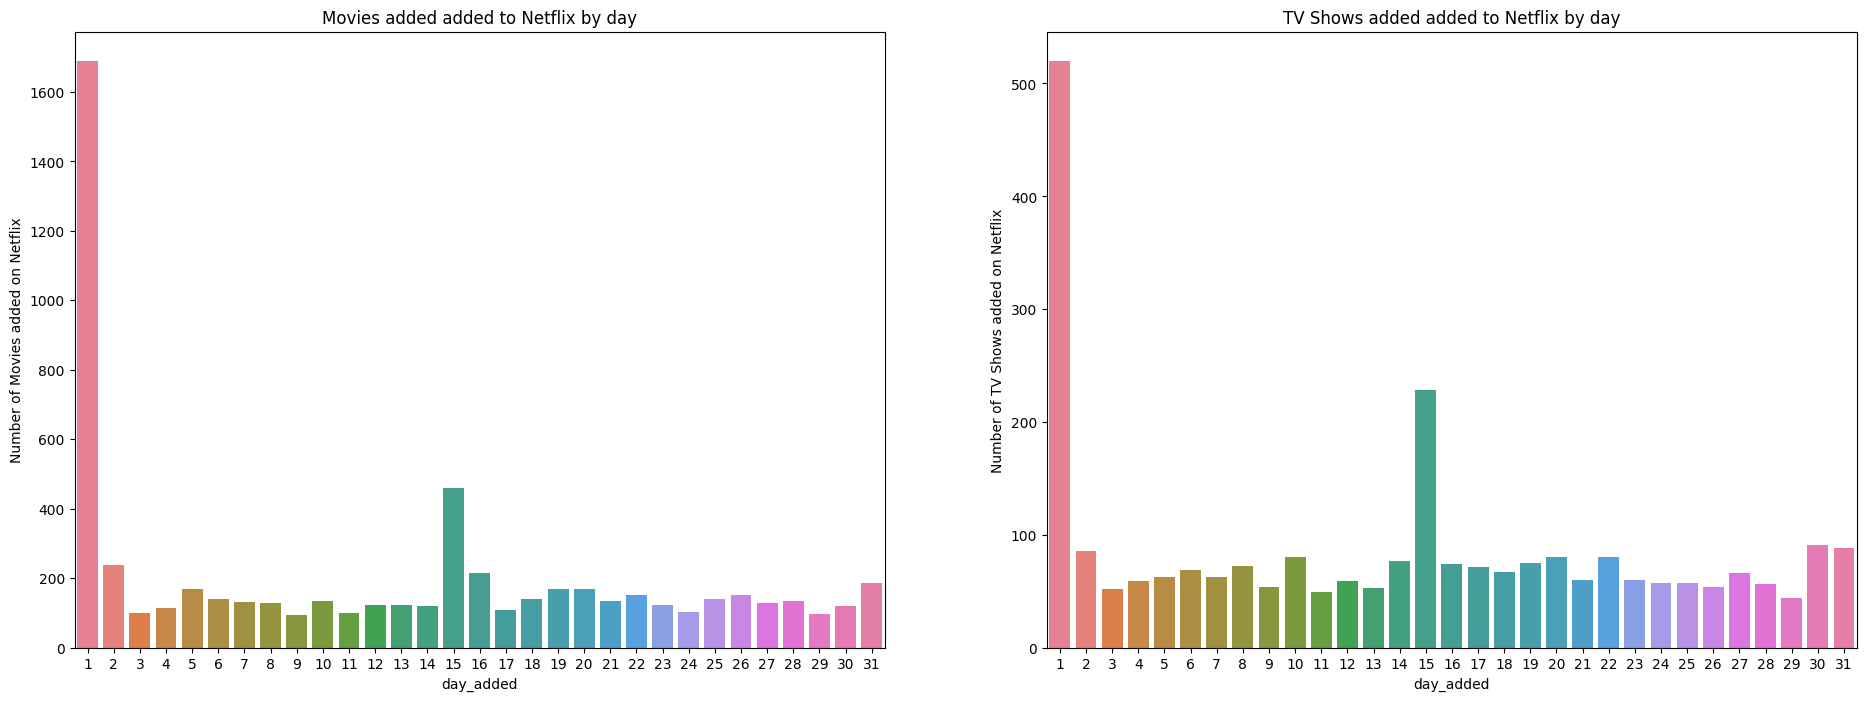

In [48]:
plt.figure(figsize=(23,8))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_day = i.groupby(['day_added']).agg({'title':'nunique'}).reset_index().sort_values(by=['day_added'],ascending=False)
  plots= sns.barplot(x = 'day_added',y='title', data = df_day, palette='husl')
  plt.title(f'{j} added added to Netflix by day')
  plt.ylabel(f"Number of {j} added on Netflix")

plt.show()


6. Total Number of Movies/TV Shows added per month on Netflix.

/tmp/ipykernel_25599/3237480195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(x = 'month_added',y='title', data = df_month, palette='husl')
/tmp/ipykernel_25599/3237480195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(x = 'month_added',y='title', data = df_month, palette='husl')


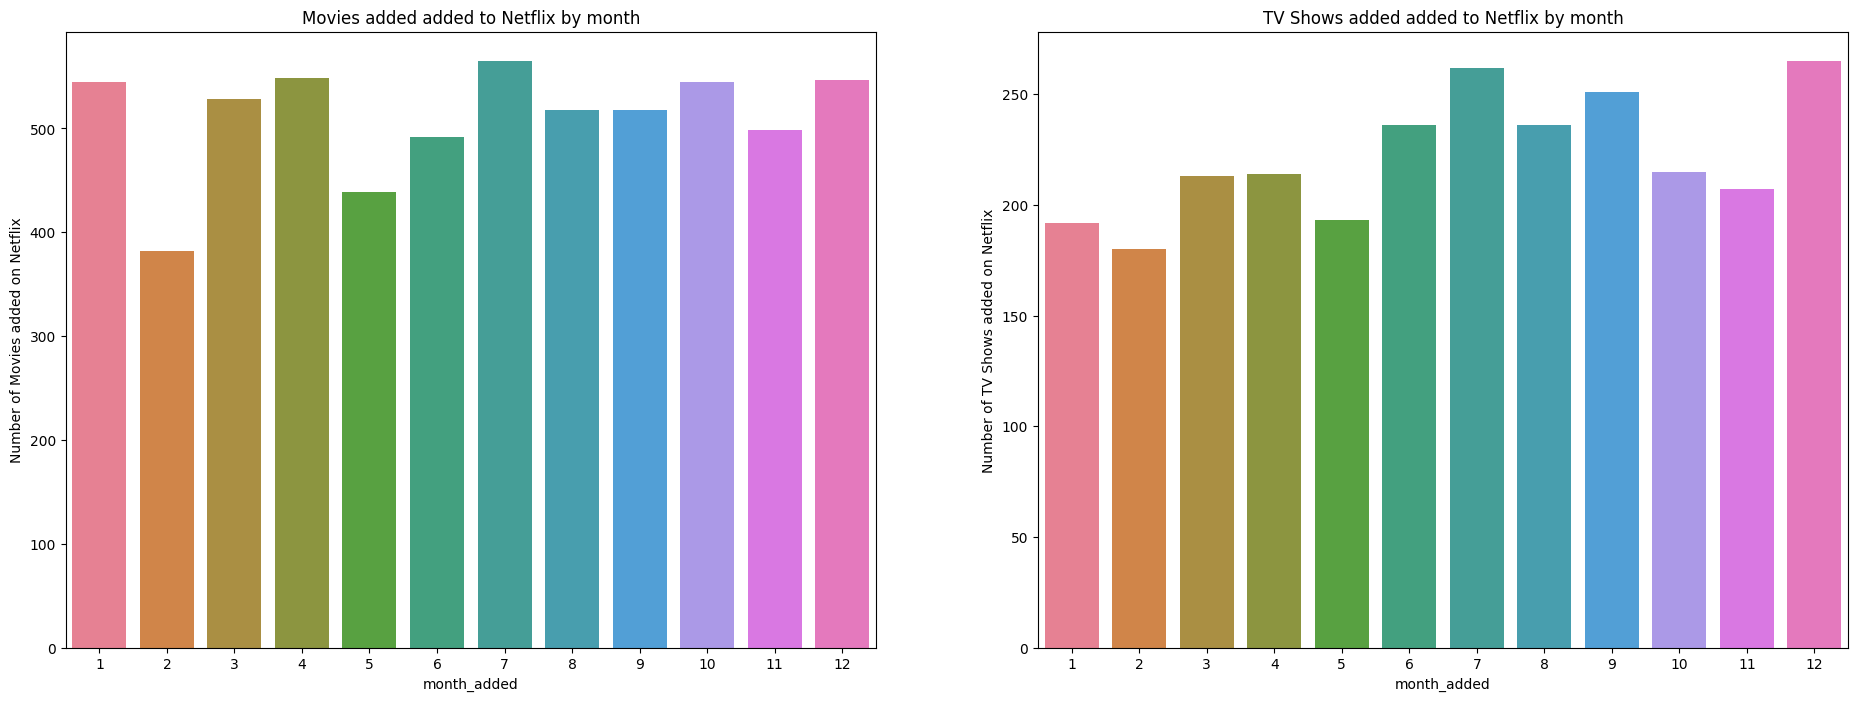

In [49]:
plt.figure(figsize=(23,8))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_month = i.groupby(['month_added']).agg({'title':'nunique'}).reset_index().sort_values(by=['month_added'],ascending=False)
  plots= sns.barplot(x = 'month_added',y='title', data = df_month, palette='husl')
  plt.title(f'{j} added added to Netflix by month')
  plt.ylabel(f"Number of {j} added on Netflix")
plt.show()

7. Total Number of Movies/TV Shows added per year on Netflix.

/tmp/ipykernel_25599/983716010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(x = 'year_added',y= 'title', data = df_country, palette='husl')
/tmp/ipykernel_25599/983716010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(x = 'year_added',y= 'title', data = df_country, palette='husl')


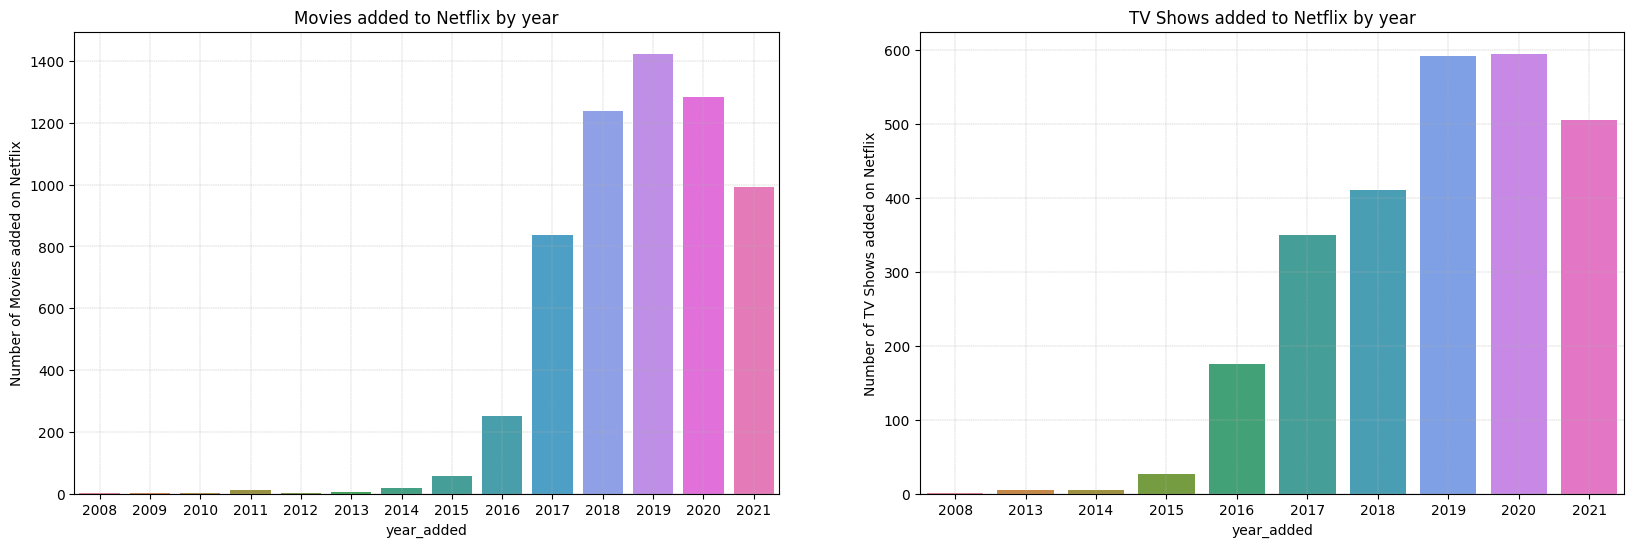

In [50]:
plt.figure(figsize=(20,6))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_country = i.groupby(['year_added']).agg({'title':'nunique'}).reset_index().sort_values(by=['year_added'],ascending=False)
  plots= sns.barplot(x = 'year_added',y= 'title', data = df_country, palette='husl')
  plt.title(f'{j} added to Netflix by year')
  plt.ylabel(f"Number of {j} added on Netflix")
  plt.grid(linestyle='--', linewidth=0.3)

plt.show()

8 Which Countries has the highest spread of Movies and TV Shows over Netflix?

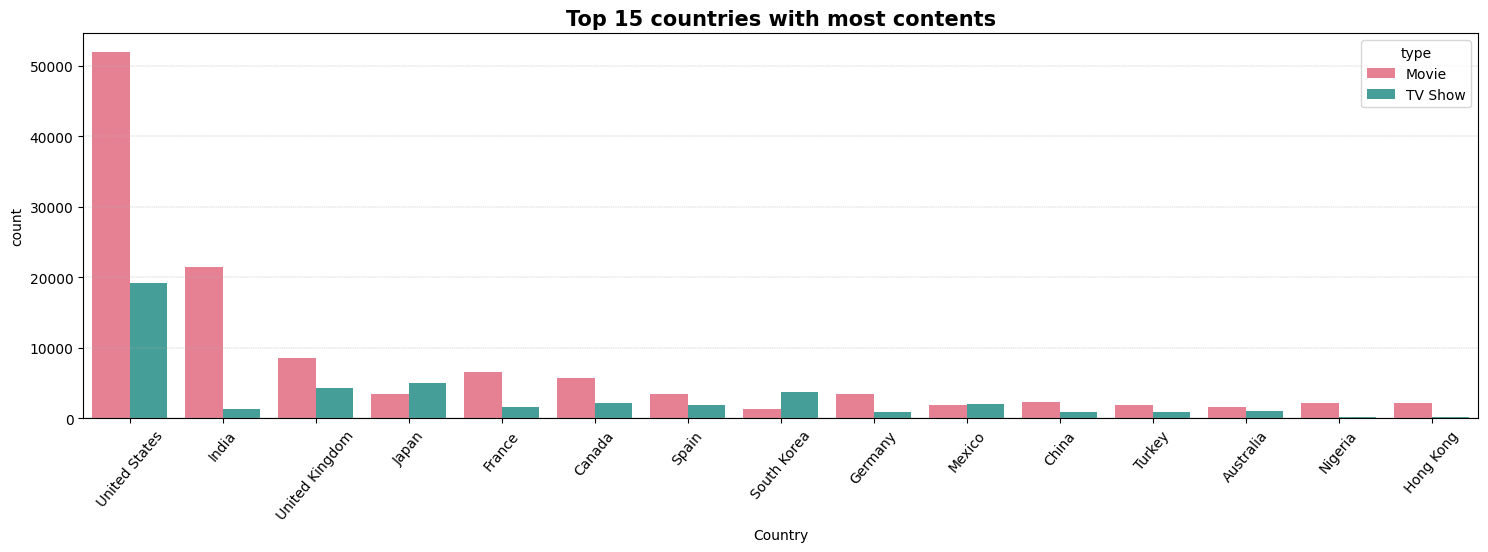

/tmp/ipykernel_25599/2041519977.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Country",x = 'title', data = df_country, palette='husl')
/tmp/ipykernel_25599/2041519977.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Country",x = 'title', data = df_country, palette='husl')


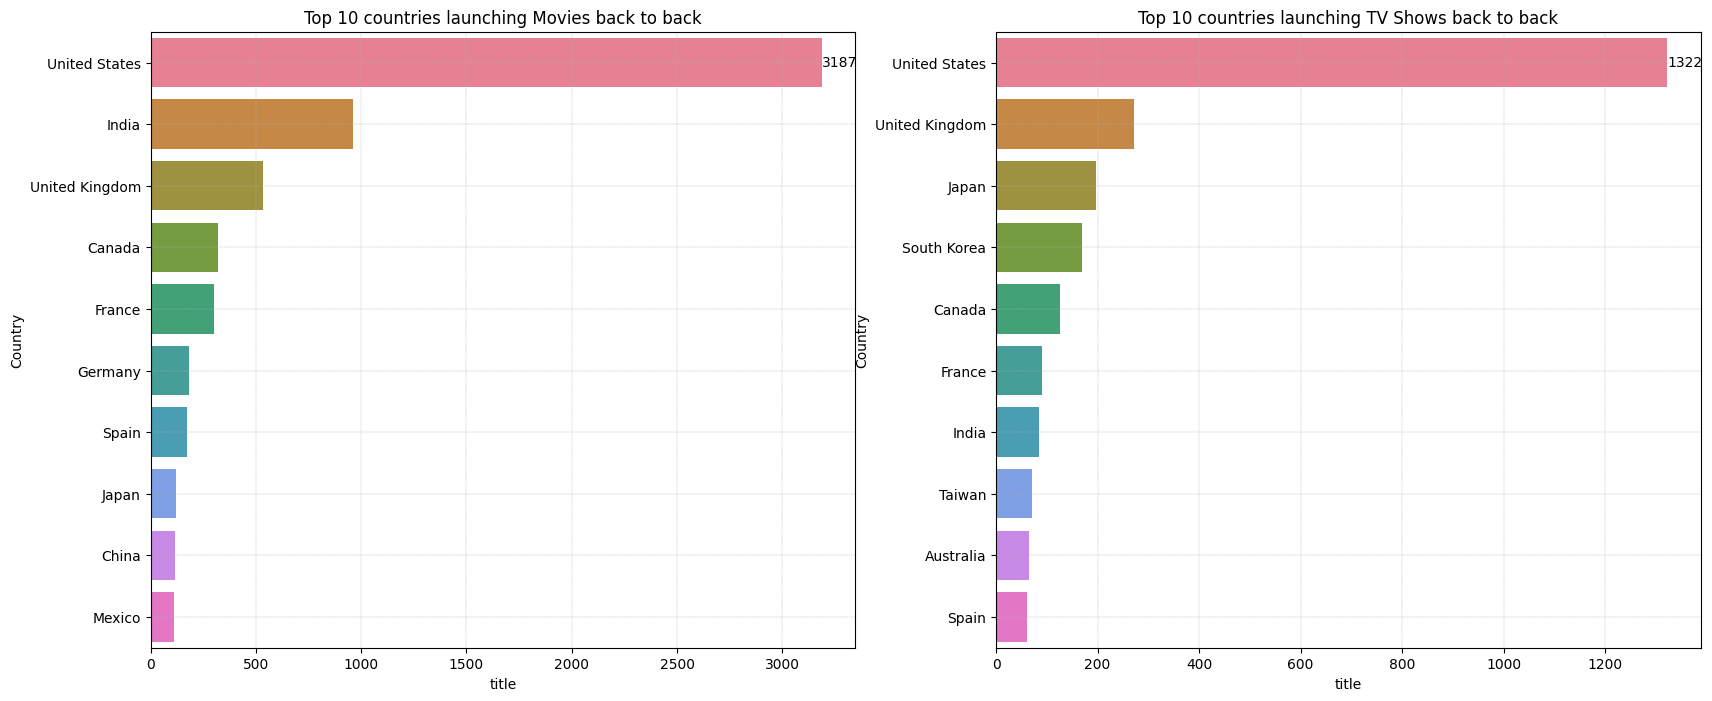

In [51]:
#Analysing top15 countries with most content
plt.figure(figsize=(18,5))
plt.grid(linestyle='--', linewidth=0.3)
sns.countplot(x=df['Country'],order=df['Country'].value_counts().index[0:15],hue=df['type'],palette ="husl")
plt.xticks(rotation=50)
plt.title('Top 15 countries with most contents', fontsize=15, fontweight='bold')
plt.show()

plt.figure(figsize=(20,8))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_country = i.groupby(['Country']).agg({'title':'nunique'}).reset_index().sort_values(by=['title'],ascending=False)[:10]
  plots= sns.barplot(y = "Country",x = 'title', data = df_country, palette='husl')
  plt.title(f'Top 10 countries launching {j} back to back')
  plt.grid(linestyle='--', linewidth=0.3)
  plots.bar_label(plots.containers[0])
plt.show()

9.Which Genres are Popular in Netflix?


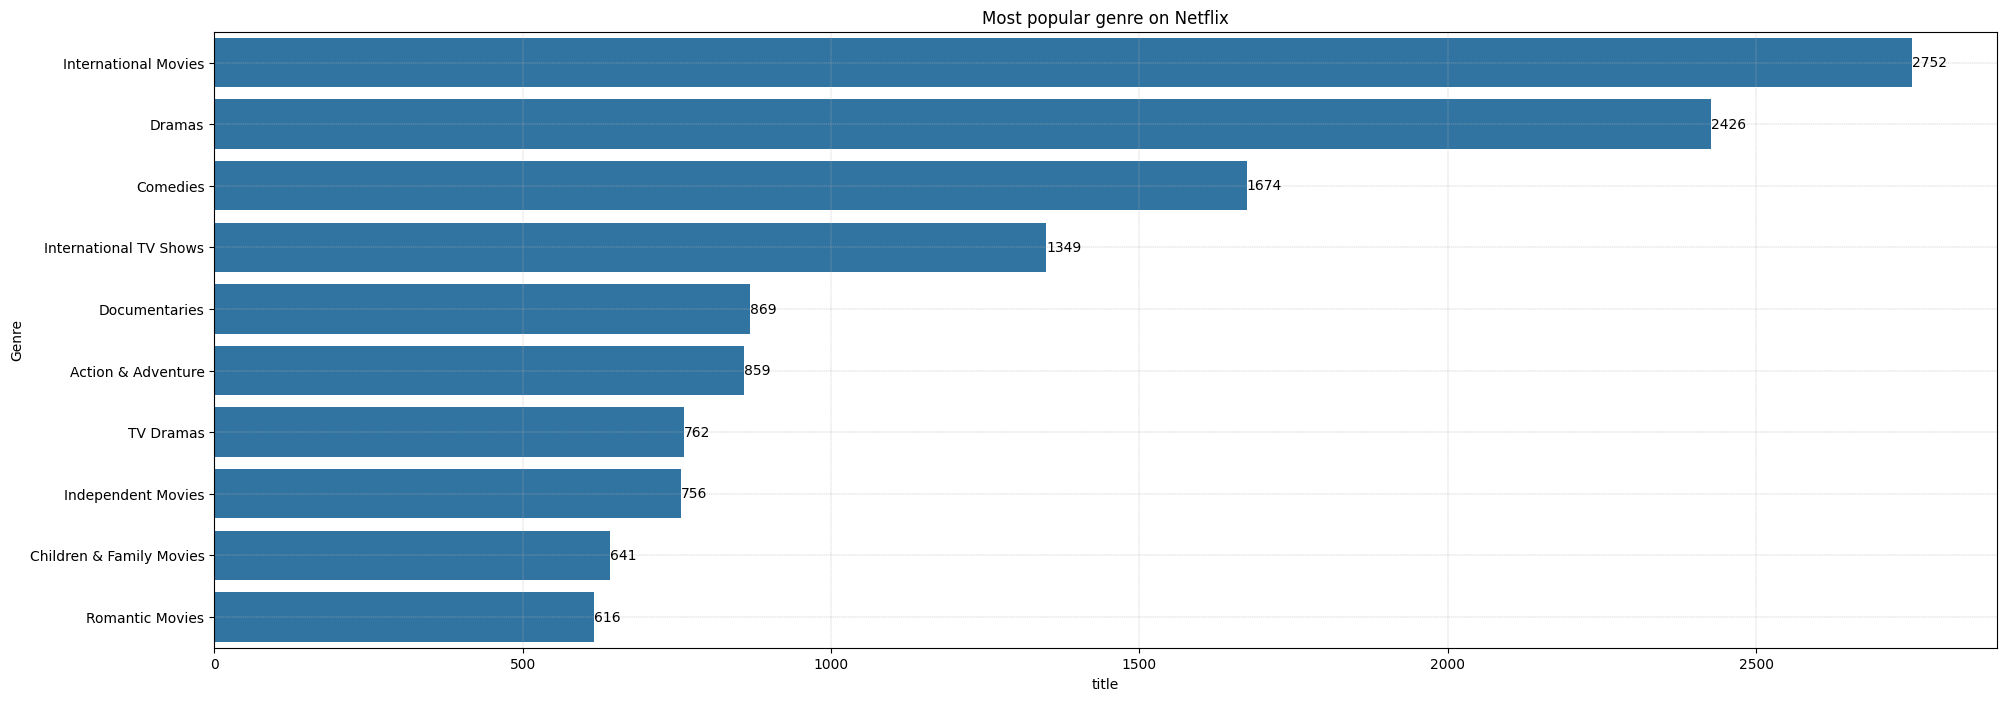

/tmp/ipykernel_25599/3142337857.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Genre",x = 'title', data = df_genre, palette='Set1')
/tmp/ipykernel_25599/3142337857.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plots= sns.barplot(y = "Genre",x = 'title', data = df_genre, palette='Set1')


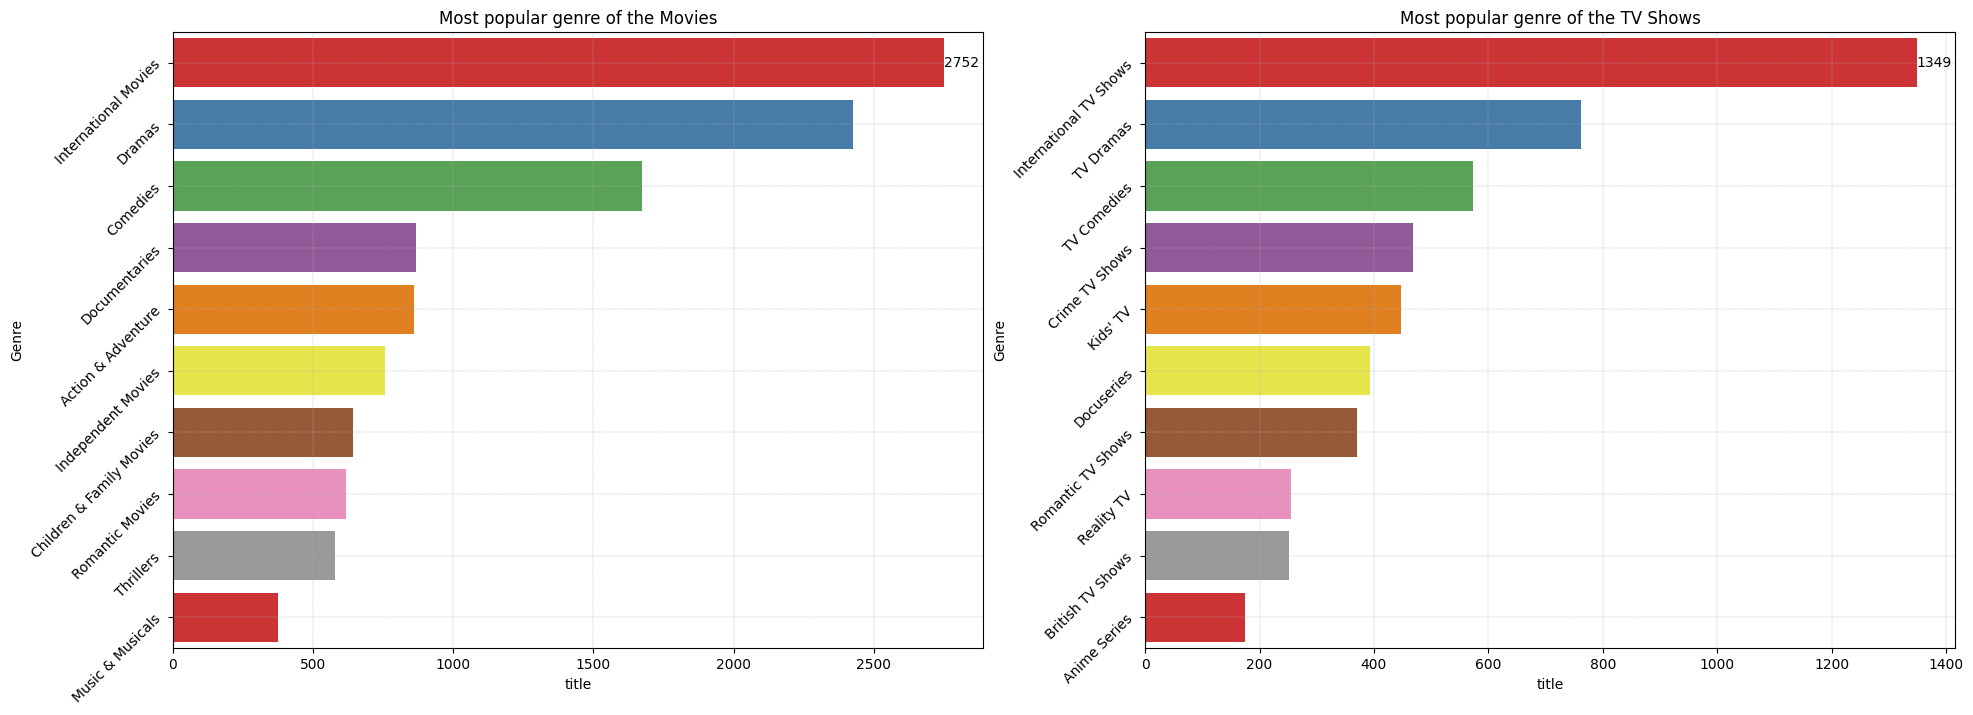

In [52]:
plt.figure(figsize=(23,8))
df_genre = df.groupby(['Genre']).agg({'title':'nunique'}).reset_index().sort_values(by=['title'],ascending=False)[:10]
plots= sns.barplot(y = "Genre",x = 'title', data = df_genre)
plt.title(f'Most popular genre on Netflix')
plt.grid(linestyle='--', linewidth=0.3)
plots.bar_label(plots.containers[0])
plt.show()

plt.figure(figsize=(23,8))
for i,j,k in ((df_movies, 'Movies',0),(df_tvshows, 'TV Shows',1)):
  plt.subplot(1,2,k+1)
  df_genre = i.groupby(['Genre']).agg({'title':'nunique'}).reset_index().sort_values(by=['title'],ascending=False)[:10]
  plots= sns.barplot(y = "Genre",x = 'title', data = df_genre, palette='Set1')
  plt.title(f'Most popular genre of the {j}')
  plt.grid(linestyle='--', linewidth=0.3)
  plots.bar_label(plots.containers[0])
  plt.yticks(rotation = 45)
plt.show()

10. What is the Day-wise number of content added in each year on Netflix?

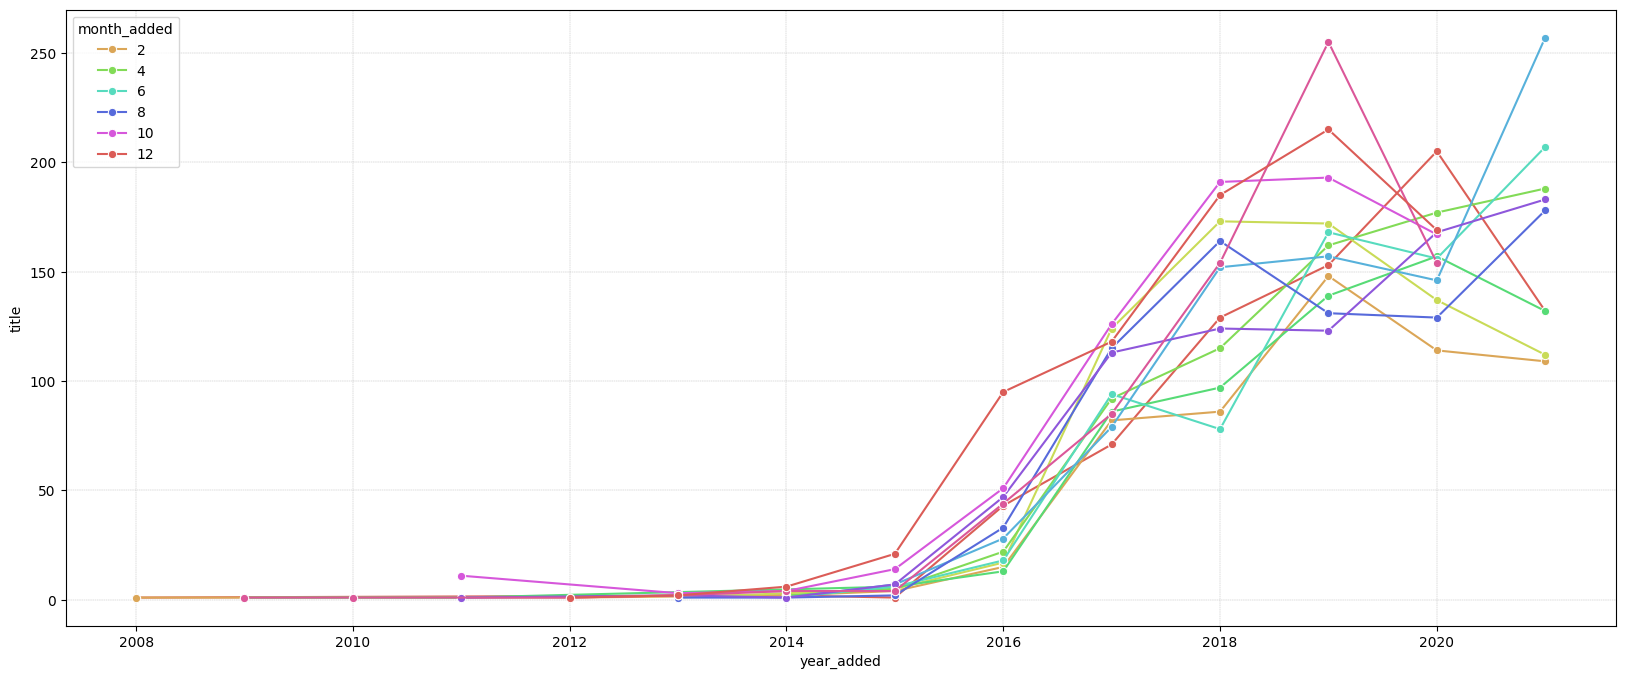

In [53]:
plt.figure(figsize=(20,8))
df_year_month = df.groupby(['year_added','month_added']).agg({'title':'nunique'}).reset_index().sort_values(by=['year_added'],ascending=False)
sns.lineplot(x = 'year_added',y='title', data = df_year_month, palette = 'hls', hue=df_year_month['month_added'], marker='o')
plt.grid(linestyle='--', linewidth=0.3)
plt.show()

11. What is the Distribution of Duration of contents over Netflix ?

/tmp/ipykernel_25599/176133064.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plots= sns.distplot(df_movies['duration'],kde=False, color=['green'])


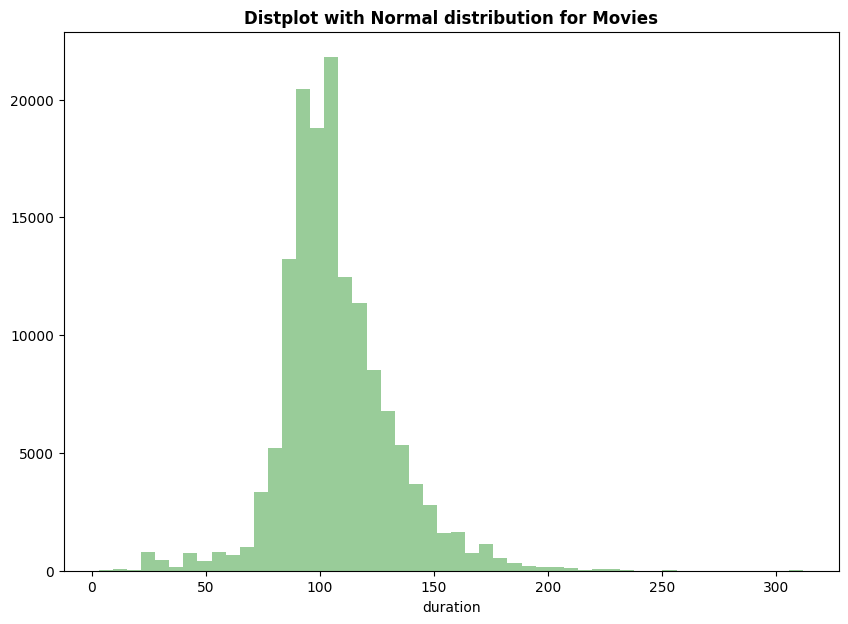

In [54]:
#Checking the distribution of Movie Durations
plt.figure(figsize=(10,7))
plots= sns.distplot(df_movies['duration'],kde=False, color=['green'])
plt.title('Distplot with Normal distribution for Movies',fontweight="bold")
plt.show()

12. What is the Distribution of Content Rating in each highest content creating countries?

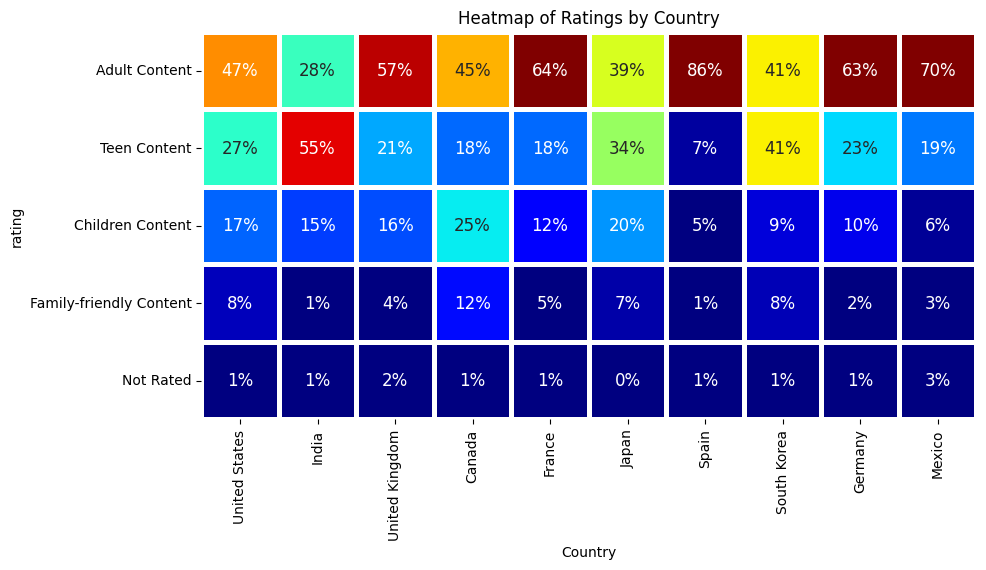

In [55]:
# Add a 'count' column for aggregation
df['count'] = 1

# Get the top 10 countries by count
top_countries = df.groupby('Country')['count'].sum().sort_values(ascending=False).head(10).index

# Filter the DataFrame for top 10 countries
df_heatmap = df[df['Country'].isin(top_countries)]

# Create a crosstab for the heatmap
df_heatmap_crosstab = pd.crosstab(df_heatmap['Country'], df_heatmap['rating'], normalize='index').T

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Defining the order of representation
country_order = ['United States', 'India', 'United Kingdom', 'Canada', 'France', 'Japan', 'Spain', 'South Korea', 'Germany', 'Mexico']
rating_order = ['Adult Content', 'Teen Content', 'Children Content', 'Family-friendly Content', 'Not Rated']

# Plotting the heatmap
sns.heatmap(df_heatmap_crosstab.loc[rating_order, country_order], cmap='jet', square=True, linewidths=2.5, cbar=False, annot=True, fmt='1.0%',
            vmax=0.6, vmin=0.05, ax=ax, annot_kws={"fontsize": 12})

plt.title('Heatmap of Ratings by Country')
plt.show()

<h1>Feature Engineering and Data Preprocessing</h1>

**Handling Missing Values**

In [56]:
df.isna().sum()

,0
title,0
Actors,0
Directors,0
Genre,0
Country,0
type,0
release_year,0
rating,0
duration,0
description,0


**Handling Outliers**

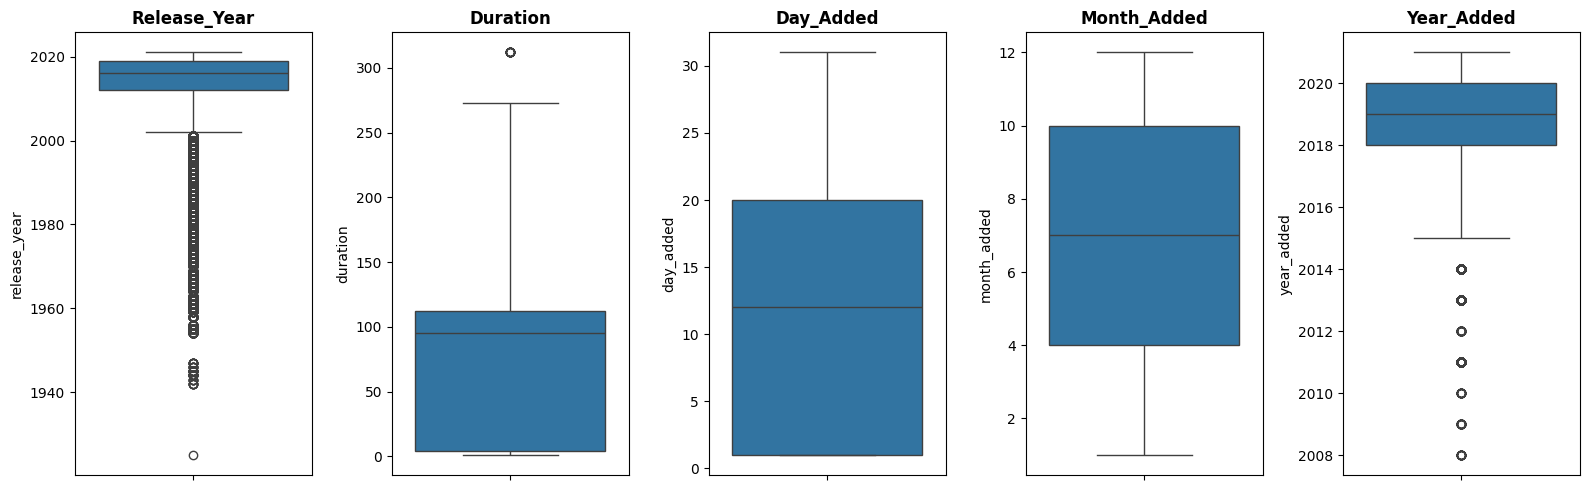

In [57]:
# Storing the continous value feature in a separate list
continous_value_feature= ["release_year","duration","day_added","month_added","year_added"]

# checking outliers with the help of box plot for continous features
plt.figure(figsize=(16,5))
for n,column in enumerate(continous_value_feature):
  plt.subplot(1, 5, n+1)
  sns.boxplot(df[column])
  plt.title(f'{column.title()}',weight='bold')
  plt.tight_layout()

Although we have some anomalies in continuous features we will not treat them by considering outliers as some of the Movies/TV Shows have been released or added early on Netflix.

**Textual Data Preprocessing**

In [58]:
# Here we are taking the copied dataframe as the data having more number of observations resulted in ram exhaustion.
df.shape, df_new.shape

((201708, 14), (8790, 12))

In [59]:
# Binning of rating in new dataframe
df_new['rating'].replace(rating_map, inplace = True)

# Checking sample after binning
df_new.shape

/tmp/ipykernel_25599/2960772512.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['rating'].replace(rating_map, inplace = True)


(8790, 12)

In [60]:
df_new.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,Teen Content,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,Adult Content,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,Adult Content,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Extract details from each textual Columns**

In [61]:
# Creating new feature content_detail with the help of other textual attributes
df_new["content_detail"]= df_new["cast"]+" "+df_new["director"]+" "+df_new["listed_in"]+" "+df_new["type"]+" "+df_new["rating"]+" "+df_new["country"]+" "+df_new["description"]

#checking the manipulation
df_new.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,Teen Content,90 min,Documentaries,"As her father nears the end of his life, filmm...",Unknown Kirsten Johnson Documentaries Movie Te...
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...","Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."


In [62]:
df_new['content_detail'][0]

'Unknown Kirsten Johnson Documentaries Movie Teen Content United States As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.'

**Lower Casing**

In [63]:
# Lower Casing
df_new['content_detail']= df_new['content_detail'].str.lower()

**Removing Punctuations**

In [64]:
# function to remove punctuations
def remove_punctuations(text):
    '''This function is used to remove the punctuations from the given sentence'''
    #imorting needed library
    import string
    # replacing the punctuations with no space, which in effect deletes the punctuation marks.
    translator = str.maketrans('', '', string.punctuation)
    # return the text stripped off punctuation marks
    return text.translate(translator)

In [65]:
df_new['content_detail']=df_new['content_detail'].apply(remove_punctuations)

In [66]:
df_new['content_detail'][0]

'unknown kirsten johnson documentaries movie teen content united states as her father nears the end of his life filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable'

**Removing URLs & Removing words and digits contain digits.**

In [67]:
def remove_url_and_numbers(text):
    '''This function is used to remove the URL's and Numbers from the given sentence'''
    # importing needed libraries
    import re
    import string

    # Replacing the URL's with no space
    url_number_pattern = re.compile(r'https?://\S+|www\.\S+')
    text= re.sub(url_number_pattern,'', text)

    # Replacing the digits with one space
    text = re.sub('[^a-zA-Z]', ' ', text)

    # return the text stripped off URL's and Numbers
    return text

In [68]:
# Remove URLs & Remove words and digits contain digits
df_new['content_detail']= df_new['content_detail'].apply(remove_url_and_numbers)

**Removing Stopwords & Removing White spaces**

In [69]:
# Downloading stopwords
nltk.download('stopwords')

# create a set of English stop words
stop_words = stopwords.words('english')

# displaying stopwords
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [70]:
def remove_stopwords_and_whitespaces(text):
    '''This function is used for removing the stopwords from the given sentence'''
    text = [word for word in text.split() if not word in stopwords.words('english')]

    # joining the list of words with space separator
    text=  " ".join(text)

    # removing whitespace
    text = re.sub(r'\s+', ' ', text)

    # return the manipulated string
    return text

In [71]:
import re
# Remove URLs & Remove words and digits contain digits
df_new['content_detail']= df_new['content_detail'].apply(remove_stopwords_and_whitespaces)

In [72]:
df_new['content_detail'][0]

'unknown kirsten johnson documentaries movie teen content united states father nears end life filmmaker kirsten johnson stages death inventive comical ways help face inevitable'

**Tokenization**

In [73]:
import spacy

# Load the SpaCy model for English
nlp = spacy.load("en_core_web_sm")

# Define a function to tokenize using SpaCy
def spacy_tokenize(text):
    doc = nlp(text)
    return [token.text for token in doc]

# Apply the tokenization to the 'content_detail' column
df_new['content_detail'] = df_new['content_detail'].apply(spacy_tokenize)

# Checking the observation after manipulation
df_new.iloc[281]['content_detail']

['mike',
 'ezuruonye',
 'juliet',
 'ochienge',
 'angela',
 'okorie',
 'huddah',
 'monroe',
 'catherine',
 'kamau',
 'naomi',
 'mburu',
 'derrick',
 'aduwo',
 'chris',
 'kamau',
 'abubakar',
 'salum',
 'celebrity',
 'landlord',
 'charles',
 'uwagbai',
 'comedies',
 'international',
 'movies',
 'movie',
 'teen',
 'content',
 'nigeria',
 'chasing',
 'wild',
 'success',
 'village',
 'hustler',
 'follows',
 'cousin',
 'nigeria',
 'kenya',
 'stumbles',
 'shady',
 'business',
 'affairs',
 'notorious',
 'overlord']

**Text Normalisation**

In [74]:
from nltk.stem import WordNetLemmatizer

wordnet = WordNetLemmatizer()

In [75]:
def lemmatizing_sentence(text):
  text = [wordnet.lemmatize(word) for word in text]

  text = " ".join(text)
  return text

In [76]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
df_new['content_detail']=df_new['content_detail'].apply(lemmatizing_sentence)

df_new.iloc[281,]['content_detail']

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


'mike ezuruonye juliet ochienge angela okorie huddah monroe catherine kamau naomi mburu derrick aduwo chris kamau abubakar salum celebrity landlord charles uwagbai comedy international movie movie teen content nigeria chasing wild success village hustler follows cousin nigeria kenya stumble shady business affair notorious overlord'

**PoS Tagging**

In [77]:
nlp = spacy.load('en_core_web_sm')

def spacy_pos_tagging(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc]

df_new['pos_tags'] = df_new['content_detail'].apply(spacy_pos_tagging)

df_new.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail,pos_tags
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,Teen Content,90 min,Documentaries,"As her father nears the end of his life, filmm...",unknown kirsten johnson documentary movie teen...,"[(unknown, ADJ), (kirsten, PROPN), (johnson, P..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",ama qamata khosi ngema gail mabalane thabang m...,"[(ama, PROPN), (qamata, PROPN), (khosi, PROPN)..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,Adult Content,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,sami bouajila tracy gotoas samuel jouy nabiha ...,"[(sami, PROPN), (bouajila, PROPN), (tracy, PRO..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,Adult Content,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",unknown unknown docuseries reality tv tv show ...,"[(unknown, ADJ), (unknown, ADJ), (docuseries, ..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,mayur jitendra kumar ranjan raj alam khan ahsa...,"[(mayur, PROPN), (jitendra, PROPN), (kumar, PR..."


**Text Vectorization**

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfv = TfidfVectorizer()  #setting max features as 30000 to avoid RAM explosion

In [80]:
X = tfidfv.fit_transform(df_new['content_detail'])

print(X.shape)

(8790, 49686)


**Dimensionality Reduction**

In [81]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=6000)
X_svd = svd.fit_transform(X)

print(svd.explained_variance_ratio_)

[7.45532566e-03 6.02647431e-03 3.49567892e-03 ... 4.67132171e-05
 4.66838576e-05 4.66430191e-05]


In [82]:
len(svd.explained_variance_ratio_)

6000

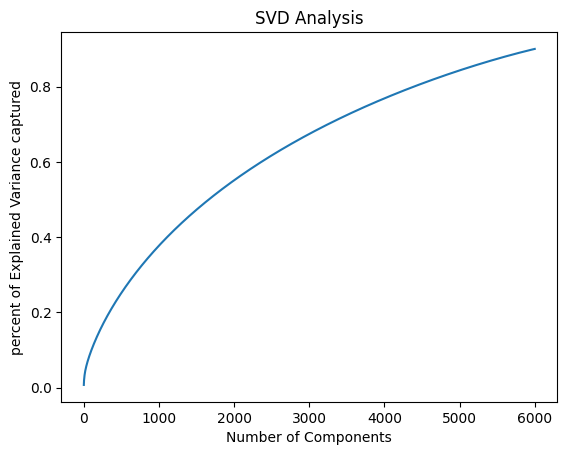

In [83]:
fig, ax = plt.subplots()
ax.plot((range(1,6001)),np.cumsum(svd.explained_variance_ratio_))
ax.set_xlabel('Number of Components')
ax.set_ylabel('percent of Explained Variance captured')
ax.set_title('SVD Analysis')
plt.show()

**ML Model Implementation**

**KMeans Clustering**

In [84]:
from sklearn.cluster import KMeans

model = KMeans(random_state=0)


In [85]:
from sklearn.metrics import silhouette_score


k_range=range(2,11)
for k in k_range:
  Kmodel= KMeans(n_clusters=k)
  labels = Kmodel.fit_predict(X_svd)
  score= silhouette_score(X_svd, labels)
  print("k=%d, Silhouette_score=%f" % (k,score))

k=2, Silhouette_score=0.009371
k=3, Silhouette_score=0.009319
k=4, Silhouette_score=0.009755
k=5, Silhouette_score=0.003742
k=6, Silhouette_score=0.007755
k=7, Silhouette_score=0.008430
k=8, Silhouette_score=0.004273
k=9, Silhouette_score=-0.000612
k=10, Silhouette_score=-0.000646


**Agglomerative Clustering**

In [ ]:
#from sklearn.cluster import AgglomerativeClustering

In [ ]:
#k_range=range(2,11)
#for k in k_range:
  #model= AgglomerativeClustering(n_clusters=k)
  #labels = model.fit_predict(X_svd)
  #score= silhouette_score(X_svd, labels)
  #print("k=%d, Silhouette_score=%f" % (k,score))

cmpare silhouette score of both the algo which are less than 0.1.indicating that data did not form meaningful clusters.Therefore not to use cluster based recommendations.

In [88]:
df_new

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail,pos_tags
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,Teen Content,90 min,Documentaries,"As her father nears the end of his life, filmm...",unknown kirsten johnson documentary movie teen...,"[(unknown, ADJ), (kirsten, PROPN), (johnson, P..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",ama qamata khosi ngema gail mabalane thabang m...,"[(ama, PROPN), (qamata, PROPN), (khosi, PROPN)..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,Adult Content,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,sami bouajila tracy gotoas samuel jouy nabiha ...,"[(sami, PROPN), (bouajila, PROPN), (tracy, PRO..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,Adult Content,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",unknown unknown docuseries reality tv tv show ...,"[(unknown, ADJ), (unknown, ADJ), (docuseries, ..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,Adult Content,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,mayur jitendra kumar ranjan raj alam khan ahsa...,"[(mayur, PROPN), (jitendra, PROPN), (kumar, PR..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,Adult Content,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",mark ruffalo jake gyllenhaal robert downey jr ...,"[(mark, PROPN), (ruffalo, PROPN), (jake, PROPN..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,United States,"July 1, 2019",2018,Family-friendly Content,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",unknown unknown kid tv korean tv show tv comed...,"[(unknown, ADJ), (unknown, ADJ), (kid, NOUN), ..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,Adult Content,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,jesse eisenberg woody harrelson emma stone abi...,"[(jesse, PROPN), (eisenberg, PROPN), (woody, P..."
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,Children Content,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",tim allen courteney cox chevy chase kate mara ...,"[(tim, PROPN), (allen, PROPN), (courteney, PRO..."


**Building Recommendation System**

In [100]:
from sklearn.metrics.pairwise import cosine_similarity
tfidf= TfidfVectorizer(stop_words='english')
tfidf_matrix= tfidf.fit_transform(df_new['content_detail'])
cosine_sim= cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_content(title, cosine_sim=cosine_sim, data=df_new, top_n=10):

    programme_list = data['title'].to_list()
    index =programme_list.index(title)
    similarity_scores = list(enumerate(cosine_sim[index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[1:11]


    recommend_index = [i[0] for i in similarity_scores]
    recommend_movie = data['title'].iloc[recommend_index]
    recommend_rating = data['rating'].iloc[recommend_index]
    recommend_country = data['country'].iloc[recommend_index]
    recommend_listed = data['listed_in'].iloc[recommend_index]
    recommend_score = [round(i[1],4) for i in similarity_scores]

    recommend_table = pd.DataFrame(list(zip(recommend_movie,recommend_rating,recommend_country,recommend_listed,recommend_score)),columns=['Recommendation','Rating','country','listed_in','Similarity_Score'])

    return recommend_table



In [101]:
recommend_content('Kota Factory')

,Recommendation,Rating,country,listed_in,Similarity_Score
0,Yeh Meri Family,Children Content,India,"International TV Shows, TV Comedies",0.1851
1,Girls Hostel,Adult Content,India,"International TV Shows, TV Comedies, TV Dramas",0.1828
2,Engineering Girls,Adult Content,India,"International TV Shows, TV Comedies",0.1644
3,Chaman Bahaar,Adult Content,India,"Comedies, Dramas, International Movies",0.1534
4,Betaal,Adult Content,India,"International TV Shows, TV Action & Adventure,...",0.1477
5,The Creative Indians,Adult Content,India,"Docuseries, International TV Shows",0.1358
6,Little Things,Adult Content,India,"International TV Shows, Romantic TV Shows, TV ...",0.1334
7,Guru Aur Bhole,Family-friendly Content,United States,"Kids' TV, TV Comedies",0.1330
8,Anjaan: Rural Myths,Teen Content,India,"International TV Shows, TV Horror, TV Thrillers",0.1261
9,The Big Day,Teen Content,India,"International TV Shows, Reality TV, Romantic T...",0.1239


In [105]:
df_new[df_new['title']=='Kota Factory'][['rating','type','country','listed_in']]

,rating,type,country,listed_in
4,Adult Content,TV Show,India,"International TV Shows, Romantic TV Shows, TV ..."


In [106]:
import pickle

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("cosine_similarity.pkl", "wb") as f:
    pickle.dump(cosine_sim, f)

with open("movies_df.pkl", "wb") as f:
    pickle.dump(df_new, f)
